**Nikhil Sunder**  
ICSRI Research Fellow, University of Miami | Open-Source Developer  
Herbert Business School, University of Miami  
B.S.B.A. Quantitative Economics & Finance; Minor in Mathematics  

**Correspondence:** nss106@miami.edu | +1 (305) 409-3108  
**Research profiles:** [GitHub](https://github.com/nikhilxsunder) · [ORCID](https://orcid.org/0009-0003-9821-3041) · [LinkedIn](https://www.linkedin.com/in/nikhilxsunder) · [Zenodo](https://zenodo.org/communities/icsri)  
**Software:** [PyPI](https://pypi.org/user/nikhilxsunder/) · [Anaconda](https://anaconda.org/conda-forge/users/nikhilxsunder)


# Reinforcement Learning Environment

This notebook implements the Hinterlang & Tanzer (2021) reinforcement-learning monetary-policy
framework. It is organized **by algorithm**: each section trains a single algorithm across the
four environments (SVAR, TVP-SVAR-SV, NARX, NSSM) and produces algorithm-specific tables and
figures. A combined section at the end overlays results across algorithms.

# Setup

## Reproducibility and runtime

The optimised policies in this notebook are produced from random initial weights, exploration noise,
and (where applicable) stochastic transitions in the underlying economy environments. To preserve
reproducibility, all random number generators (Python, NumPy, PyTorch, the Stable-Baselines3
environment vectoriser, and PyMC) are seeded at the start of the notebook, and the algorithm
hyper-parameters are stated explicitly in their respective sections.

The transition equations for the four economies are estimated in the *linear* and *non-linear*
environment notebooks of this project. To avoid re-fitting them here we execute those notebooks
at the top of this one via the IPython `%run` magic. The resulting variables (the fitted SVAR,
the TVP-SVAR-SV posterior, the NARX networks and scalers, and the fitted NSSM) are then used
directly to drive the RL environments below.

## Software and libraries

Both parent notebooks install their own dependencies (`fedfred`, PyMC, PyTensor, PyTorch,
`statsmodels`); this notebook additionally installs Stable-Baselines3 (Raffin et al., 2021),
`gymnasium` (Towers et al., 2023), and `tqdm`.


In [1]:
%pip install stable-baselines3 gymnasium tqdm --quiet

Note: you may need to restart the kernel to use updated packages.


## Running the parent notebooks

The `%run` magic executes another `.ipynb` file in the current kernel, so every top-level variable
defined in those notebooks becomes available here. The `%%capture` magic suppresses each parent
notebook's stdout, plots, and warnings so the output of this notebook stays focused on the RL
exercise.


In [2]:
%%capture
%run linear_environment.ipynb

In [3]:
%%capture
%run nonlinear_environment.ipynb

In [4]:
# Sanity check: confirm that the parent notebooks have populated the expected names.
expected_from_linear = ["df", "svar", "idata_y", "idata_pi"]
expected_from_nonlinear = [
    "final_narx_y", "final_narx_pi",
    "x_scaler_y", "y_scaler_y", "x_scaler_pi", "y_scaler_pi",
    "nssm", "state_dim_y", "state_dim_pi",
    "h0_y_nssm", "h0_pi_nssm",
    "states_y_nssm", "states_pi_nssm",
    "fit_narx", "fit_nssm",
]
missing = [name for name in expected_from_linear + expected_from_nonlinear if name not in globals()]
if missing:
    raise RuntimeError(
        "Expected variables missing from globals after %run of parent notebooks: "
        + ", ".join(missing)
    )
print("Parent notebooks ran successfully. Detected:")
print(f"  df: {df.shape}, columns = {list(df.columns)}")
print(f"  svar.mod_y regressors: {list(svar.mod_y.params.index)}")
print(f"  svar.mod_pi regressors: {list(svar.mod_pi.params.index)}")
print(f"  TVP idata_y posterior shape: beta = {idata_y.posterior['beta'].shape}")
print(f"  NARX final_narx_y input_size = {final_narx_y.input_size}")
print(f"  NARX final_narx_pi input_size = {final_narx_pi.input_size}")
print(f"  NSSM state_dim_y = {state_dim_y}, state_dim_pi = {state_dim_pi}")
print(f"  NSSM states_y_nssm shape = {tuple(states_y_nssm.shape)}")

Parent notebooks ran successfully. Detected:
  df: (80, 3), columns = ['pi', 'y', 'i']
  svar.mod_y regressors: ['const', 'y_lag1', 'y_lag2', 'pi_lag1', 'pi_lag2', 'i_lag1', 'i_lag2']
  svar.mod_pi regressors: ['const', 'y', 'y_lag1', 'y_lag2', 'pi_lag1', 'pi_lag2', 'i_lag1', 'i_lag2']
  TVP idata_y posterior shape: beta = (2, 800, 153, 7)
  NARX final_narx_y input_size = 3
  NARX final_narx_pi input_size = 6
  NSSM state_dim_y = 4, state_dim_pi = 4
  NSSM states_y_nssm shape = (78, 4)


## Imports specific to this notebook

The parent notebooks already imported `numpy`, `pandas`, `torch`, and the macro-environment
specifics. This block adds the Stable-Baselines3 surface, `gymnasium`, and helpers used by the
RL infrastructure.


In [5]:
# Imports specific to this notebook (parent notebooks already imported numpy, pandas, torch, etc.)
from __future__ import annotations
from dataclasses import dataclass, field
from typing import Any, Callable, Dict, List, Optional, Sequence, Tuple

import warnings

import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import DDPG, SAC
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.torch_layers import create_mlp
from stable_baselines3.common.preprocessing import get_action_dim
from stable_baselines3.td3.policies import Actor as TD3Actor, TD3Policy

import pandas as pd
import numpy as np

import torch
import torch.nn as nn

warnings.filterwarnings("ignore", category=UserWarning)

## Reinforcement-learning framework

### Methodological framing

The reinforcement-learning (RL) setup follows the two-stage architecture proposed by Hinterlang
& Tanzer (2021) in Deutsche Bundesbank Discussion Paper No. 51/2021. In the first stage, the
transition equations of the macro-economy are estimated from observable data; in the second
stage, an RL agent learns an interest-rate reaction function by interacting with the estimated
economy, treating the transition equations as a fixed environment. Stage one is handled entirely
by the linear- and non-linear-environment notebooks of this project. The four fitted environments
(restricted recursive SVAR(2), TVP-SVAR-SV, restricted NARX, and two-block NSSM) are imported as-is.

The conceptual foundations of RL are due to Bellman (1957) and Howard (1960), and the modern
algorithmic treatment is due to Sutton & Barto (2018). We implement two off-policy deep-RL
algorithms via Stable-Baselines3 (Raffin et al., 2021) - the Deep Deterministic Policy Gradient
(DDPG) algorithm of Lillicrap et al. (2015) and the Soft Actor-Critic (SAC) algorithm of Haarnoja
et al. (2018) - and a custom tabular Q-learning implementation that matches Watkins (1989) and
Watkins & Dayan (1992).

### Observation space (H&T eq. 9-10)

Both observation specifications are trained for every applicable cell:

$$x_t^{(1)} = (y_t, \pi_t), \qquad x_t^{(2)} = (y_t, y_{t-1}, \pi_t, \pi_{t-1}).$$

The first mirrors the Taylor (1993) information set. The second adds one lag of each macro
variable, which Hawkins et al. (2015) report produces more stabilising behaviour.

### Action space and the zero lower bound (H&T eq. 11)

Stable-Baselines3 expects continuous-action spaces normalised to $[-1, 1]$ for stable training.
We therefore expose the action space as $a_t \in [-1, 1]$ and map it inside the environment to
$i_t = \frac{1}{2}(a_t + 1) \cdot i_{\max}$. This realises Hinterlang & Tanzer (2021, eq. 11)
for the ZLB: the lower clip at $a = -1$ corresponds exactly to $i_t = 0$. The upper clip at
$i_{\max} = 15\%$ is a maintained assumption that is non-binding over the 1987Q3-2007Q2 training
sample.

### Reward function (H&T eq. 16, fn. 13, plus Sack-Wieland 2000 smoothing)

We adopt the quadratic mandate reward of Hinterlang & Tanzer (2021, eq. 16) augmented with the
interest-rate smoothing term of Sack & Wieland (2000):

$$r_t(x_t, i_t) = -\omega_\pi (\pi_{t+1} - \pi^*)^2 - \omega_y y_{t+1}^2 - \omega_{\Delta i} (i_t - i_{t-1})^2,$$

with $\omega_\pi = \omega_y = \omega_{\Delta i} = 0.5$ and $\pi^* = 2\%$. Footnote 13 of
Hinterlang & Tanzer (2021) augments this with a soft penalty when the squared deviations of $\pi$
or $y$ exceed 4 (i.e., when the absolute deviation exceeds 2 percentage points). The
$(\Delta i)^2$ term is not in H&T eq. 16 as written, but H&T's Table 7 explicitly reports
$\mathrm{Var}(\Delta i)$ as a model-comparison metric; without the smoothing term, the agent
learns a globally optimal bang-bang policy because the SVAR's coefficient on $i_{t-1}$ in the
output-gap equation is only $-0.05$, so only large rate swings exert any control. Standard
references for the term: Sack & Wieland (2000), Woodford (2003, ch. 6), Svensson (2020).

### Episode design (H&T Section 2.2)

$M = 500$ episodes per architecture. Each episode is initialised from the empirical distribution
of the training-sample data (1987Q3 to 2007Q2), then rolled forward for up to $T = 50$ quarters;
the episode terminates early when the macro state reaches the band $1.7 < \pi_{t+1} < 2.3$ and
$|y_{t+1}| < 0.3$. The discount factor is $\gamma = 0.99$ (Svensson, 2020).


In [6]:
# Hyper-parameters (Hinterlang & Tanzer 2021, Section 2)
PI_STAR = 2.0
OMEGA_PI = 0.5
OMEGA_Y = 0.5
OMEGA_DI = 0.5    # Sack-Wieland (2000) interest-rate smoothing weight on (i_t - i_{t-1})^2.
                  # H&T (2021) eq. 16 omits this term, but their Table 7 reports Var(Delta i)
                  # as a model-comparison metric. Without it, the agent learns a globally
                  # optimal bang-bang policy (i flips 0 <-> ACTION_HIGH each quarter) because
                  # the SVAR's coefficient on i_lag1 is small and only large rate swings
                  # exert any control. Standard reference: Woodford (2003, ch. 6), Svensson (2020).
GAMMA = 0.99
T_MAX = 50
ACTION_LOW = 0.0
ACTION_HIGH = 15.0
PENALTY_BAND = 2.0
PENALTY_WEIGHT = 10.0
STOP_PI_BAND = 0.3
STOP_Y_BAND = 0.3

# Macro-state safety clamp. The fitted environments (especially the NSSM) extrapolate
# poorly outside their training-sample range. We clip pi and y to a wide but finite
# band so a single divergent trajectory cannot drag the agent-selection filter to -inf.
# This is a downstream band-aid; the proper fix is to retrain the NSSM with stability
# constraints (Saxe-McClelland-Ganguli init, spectral regularization on W_h, or weight-tying
# to a contraction map). Set MACRO_CLAMP_PI = MACRO_CLAMP_Y = np.inf to disable.
MACRO_CLAMP_PI = 10.0   # |pi - PI_STAR| capped at 10 percentage points
MACRO_CLAMP_Y  = 10.0   # |y| capped at 10 percentage points

# H&T agent-selection criteria
SELECT_ER_ES_MIN = -4.0          # H&T (2021) original threshold; kept for documentation
SELECT_ER_ES_MIN_SEARCH = -50.0  # looser threshold for candidate saving during training
SELECT_ES_MIN = 1
SELECT_ES_MAX = T_MAX + 1   # filter accepts ES in (1, T_MAX]; the old value 50 silently rejected truncated episodes (ES == T_MAX)

# Training budget per cell
M_EPISODES = 500
TOTAL_TIMESTEPS = 12_500

# Architecture-search grid
FULL_GRID = False
if FULL_GRID:
    CRITIC_NODE_GRID = (1, 2, 3, 4, 5, 6, 7, 8, 9, 10)
    ACTOR_NODE_GRID_NONLINEAR = (1, 2, 3, 4, 5, 6, 7, 8, 9, 10)
else:
    CRITIC_NODE_GRID = (1, 2)
    ACTOR_NODE_GRID_NONLINEAR = (1, 4, 8)

SS_ROLLOUT_STEPS = 100
CANDIDATE_SAVE_EVERY = 5

Q_EPISODES = 2_000

# Reset seeds for this notebook (parent notebooks may have changed RNG state)
SEED = 2026
import random
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


def cb_reward(pi_next: float, y_next: float, i_t: float = 0.0,
              i_prev: float = 0.0) -> float:
    """Central-bank reward: H&T (2021, eq. 16 + fn. 13) plus Sack-Wieland smoothing.

    H&T eq. 16:           r = -omega_pi (pi-pi*)^2 - omega_y y^2
    H&T fn. 13:           additional -PENALTY_WEIGHT * (deviation)^2 when |dev| > 2pp
    Sack-Wieland (2000):  additional -omega_di (i_t - i_{t-1})^2  (set OMEGA_DI=0 to disable)

    The Sack-Wieland term is needed in practice because H&T eq. 16 alone is bang-bang
    optimal when the underlying environment has weak interest-rate transmission (the SVAR
    has only -0.05 on i_lag1 in the y-equation), and bang-bang policies score well on the
    mandate even though no real central bank would execute them.
    """
    base = (-OMEGA_PI * (pi_next - PI_STAR) ** 2
            - OMEGA_Y * y_next ** 2
            - OMEGA_DI * (i_t - i_prev) ** 2)
    penalty = 0.0
    if abs(pi_next - PI_STAR) > PENALTY_BAND:
        penalty -= PENALTY_WEIGHT * (pi_next - PI_STAR) ** 2
    if abs(y_next) > PENALTY_BAND:
        penalty -= PENALTY_WEIGHT * y_next ** 2
    return float(base + penalty)


def is_terminal(pi_next: float, y_next: float) -> bool:
    return (
        abs(pi_next - PI_STAR) < STOP_PI_BAND
        and abs(y_next) < STOP_Y_BAND
    )


def normalised_to_rate(action: np.ndarray) -> float:
    a = float(np.asarray(action).reshape(-1)[0])
    a = float(np.clip(a, -1.0, 1.0))
    return 0.5 * (a + 1.0) * ACTION_HIGH


def rate_to_normalised(rate: float) -> np.ndarray:
    a = 2.0 * float(rate) / ACTION_HIGH - 1.0
    return np.array([np.clip(a, -1.0, 1.0)], dtype=np.float32)


## Economy environments

`MonetaryEnv` subclasses `gymnasium.Env` and supports both observation specifications via the
`observation_lag` flag. Each concrete environment manages its own state buffers (lags of
inflation, output gap, and the policy rate) and exposes a `reset` and `step` method compliant
with Gymnasium (Towers et al., 2023).

**Action-time convention.** When the agent at period $t$ selects action $i_t$, this rate enters
the *next* period's transition equation as the "one-quarter-lagged" rate $i_{t-1}^{(\text{next})}$,
and the previous rate $i_{t-1}$ becomes the two-quarter-lagged $i_{t-2}^{(\text{next})}$. This is
the H&T recursive identification convention: the policy rate affects $y$ and $\pi$ with at least
a one-period lag (Rotemberg & Woodford, 1997; Orphanides & Wieland, 2000).


In [7]:
class MonetaryEnv(gym.Env):
    """Base monetary-policy environment.

    Concrete subclasses implement `_transition`, which maps the current internal
    state and the chosen interest rate i_t to the next pair (pi_{t+1}, y_{t+1}).
    """

    metadata = {"render_modes": []}

    def __init__(self, df_train: pd.DataFrame, *, observation_lag: bool = False,
                 seed: int = SEED):
        super().__init__()
        self.df_train = df_train.copy()
        self.observation_lag = observation_lag
        self.rng = np.random.default_rng(seed)

        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(1,), dtype=np.float32)
        obs_dim = 4 if observation_lag else 2
        self.observation_space = spaces.Box(
            low=np.array([-10.0] * obs_dim, dtype=np.float32),
            high=np.array([10.0] * obs_dim, dtype=np.float32),
            dtype=np.float32,
        )

        self._pi_hist: List[float] = []
        self._y_hist: List[float] = []
        self._i_hist: List[float] = []
        self.t: int = 0

    @property
    def obs_dim(self) -> int:
        return 4 if self.observation_lag else 2

    def _sample_init_state(self) -> Dict[str, float]:
        idx = self.rng.integers(low=2, high=len(self.df_train))
        block = self.df_train.iloc[idx - 2 : idx]
        return {
            "pi_t":   float(block["pi"].iloc[1]),
            "pi_tm1": float(block["pi"].iloc[0]),
            "y_t":    float(block["y"].iloc[1]),
            "y_tm1":  float(block["y"].iloc[0]),
            "i_t":    float(block["i"].iloc[1]),
            "i_tm1":  float(block["i"].iloc[0]),
        }

    def _init_buffers(self, init_state: Dict[str, float]) -> None:
        self._pi_hist = [init_state["pi_tm1"], init_state["pi_t"]]
        self._y_hist = [init_state["y_tm1"], init_state["y_t"]]
        self._i_hist = [init_state["i_tm1"], init_state["i_t"]]

    def _push(self, pi_new: float, y_new: float, i_new: float) -> None:
        self._pi_hist.append(pi_new)
        self._y_hist.append(y_new)
        self._i_hist.append(i_new)
        self._pi_hist = self._pi_hist[-3:]
        self._y_hist = self._y_hist[-3:]
        self._i_hist = self._i_hist[-3:]

    def _observation(self) -> np.ndarray:
        if self.observation_lag:
            obs = [self._y_hist[-1], self._y_hist[-2], self._pi_hist[-1], self._pi_hist[-2]]
        else:
            obs = [self._y_hist[-1], self._pi_hist[-1]]
        return np.asarray(obs, dtype=np.float32)

    def reset(self, *, seed: Optional[int] = None,
              options: Optional[Dict[str, Any]] = None) -> Tuple[np.ndarray, Dict[str, Any]]:
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        self.t = 0
        init_state = (options or {}).get("init_state") if options else None
        if init_state is None:
            init_state = self._sample_init_state()
        self._init_buffers(init_state)
        return self._observation(), {}

    def _transition(self, i_t: float) -> Tuple[float, float]:
        raise NotImplementedError

    def step(self, action: np.ndarray) -> Tuple[np.ndarray, float, bool, bool, Dict[str, Any]]:
        i_t = float(normalised_to_rate(action))
        # NOTE: _transition returns (y_new, pi_new) to match the SVAR ordering used in each
        # subclass. Unpacking in that order is the canonical fix for the swap bug that
        # destabilized the SVAR and NSSM closed loops.
        # Capture the previous rate before pushing the new one, so the smoothing term in
        # cb_reward sees the correct (i_t, i_{t-1}) pair.
        i_prev = self._i_hist[-1] if self._i_hist else i_t
        y_next, pi_next = self._transition(i_t)
        # Defensive macro-state clamp. Bounds the trajectory so the agent-selection callback
        # is not dominated by a single divergent excursion. See cell 17 for MACRO_CLAMP_*.
        pi_next = float(np.clip(pi_next, PI_STAR - MACRO_CLAMP_PI, PI_STAR + MACRO_CLAMP_PI))
        y_next  = float(np.clip(y_next,  -MACRO_CLAMP_Y, MACRO_CLAMP_Y))
        self._push(pi_next, y_next, i_t)
        reward = cb_reward(pi_next, y_next, i_t, i_prev)
        self.t += 1
        terminated = bool(is_terminal(pi_next, y_next))
        truncated = bool(self.t >= T_MAX)
        info = {"pi": pi_next, "y": y_next, "i": i_t}
        return self._observation(), reward, terminated, truncated, info


### Linear environment: restricted recursive SVAR(2)

Wraps the fitted `svar` object from the linear-environment notebook. The OLS coefficient names
(`svar.mod_y.params.index`, `svar.mod_pi.params.index`) are looked up dynamically so the
environment adapts to whatever lag restriction the parent notebook applied. The structural
shocks use the OLS residual standard deviations as their innovation variance.


In [8]:
# Extract OLS residual sigmas from the fitted SVAR
_svar_sigma_y = float(np.std(svar.mod_y.resid, ddof=int(svar.mod_y.df_model) + 1))
_svar_sigma_pi = float(np.std(svar.mod_pi.resid, ddof=int(svar.mod_pi.df_model) + 1))


class SVAREnv(MonetaryEnv):
    """Linear monetary-policy environment driven by the parent notebook's SVAR."""

    def __init__(self, df_train: pd.DataFrame, *, observation_lag: bool = False,
                 seed: int = SEED):
        super().__init__(df_train, observation_lag=observation_lag, seed=seed)
        self.params_y = svar.mod_y.params  # pandas Series
        self.params_pi = svar.mod_pi.params
        self.sigma_y = _svar_sigma_y
        self.sigma_pi = _svar_sigma_pi

    def _transition(self, i_t: float) -> Tuple[float, float]:
        # Build the regressor dictionary for predicting y_{t+1} and pi_{t+1}.
        # Mapping convention: the agent's action i_t becomes i_lag1 for the
        # *next* period (one quarter back from t+1), and the buffer's most
        # recent rate i_{t-1} becomes i_lag2 (two quarters back from t+1).
        y_lag1 = self._y_hist[-1]      # = y_t
        y_lag2 = self._y_hist[-2]      # = y_{t-1}
        pi_lag1 = self._pi_hist[-1]    # = pi_t
        pi_lag2 = self._pi_hist[-2]    # = pi_{t-1}
        i_lag1 = i_t                   # action becomes lag-1
        i_lag2 = self._i_hist[-1]      # previous rate becomes lag-2

        eps_y = float(self.rng.normal(scale=self.sigma_y))
        eps_pi = float(self.rng.normal(scale=self.sigma_pi))

        # y-equation: linear combination over whichever regressors the parent fit kept
        all_vals_y = {
            "const": 1.0,
            "y_lag1": y_lag1, "y_lag2": y_lag2,
            "pi_lag1": pi_lag1, "pi_lag2": pi_lag2,
            "i_lag1": i_lag1, "i_lag2": i_lag2,
        }
        y_new = sum(float(self.params_y[k]) * all_vals_y.get(k, 0.0)
                    for k in self.params_y.index) + eps_y

        # pi-equation: recursive identification places contemporaneous y_{t+1}
        # in the inflation regressor set.
        all_vals_pi = {
            "const": 1.0,
            "y": y_new,
            "y_lag1": y_lag1, "y_lag2": y_lag2,
            "pi_lag1": pi_lag1, "pi_lag2": pi_lag2,
            "i_lag1": i_lag1, "i_lag2": i_lag2,
        }
        pi_new = sum(float(self.params_pi[k]) * all_vals_pi.get(k, 0.0)
                     for k in self.params_pi.index) + eps_pi

        return float(y_new), float(pi_new)


check_env(SVAREnv(df), warn=True, skip_render_check=True)
print(f"SVAREnv passes the SB3 env-checker.")
print(f"  sigma_y  = {_svar_sigma_y:.4f}")
print(f"  sigma_pi = {_svar_sigma_pi:.4f}")

SVAREnv passes the SB3 env-checker.
  sigma_y  = 0.4814
  sigma_pi = 0.1849


### Modern linear environment: TVP-SVAR-SV

Wraps the PyMC posteriors `idata_y` and `idata_pi` from the linear-environment notebook. For
each RL rollout we anchor the time-varying coefficient state at the end-of-training-sample
posterior mean (i.e., the smoothed coefficient at 2007Q2), following the counterfactual design
of Primiceri (2005, Section 4.4). The stochastic-volatility process is anchored at the same
time slice.


In [9]:
# Identify the index for 2007Q2 in the TVP posteriors so we can anchor at end-of-training
_tvp_time_coord = idata_y.posterior["beta"].coords["time"].values  # integer index
# The TVP design is built on idx_tvp (a PeriodIndex) defined in the linear notebook.
_period_end = pd.Period("2007Q2", freq="Q")
_tvp_end_idx = idx_tvp.get_loc(_period_end)

# Posterior means at the training endpoint
_B_y_T = idata_y.posterior["beta"].mean(("chain", "draw")).isel(time=_tvp_end_idx).values
_B_pi_T = idata_pi.posterior["beta"].mean(("chain", "draw")).isel(time=_tvp_end_idx).values
_sigma_y_T = float(
    idata_y.posterior["sigma_obs"].mean(("chain", "draw")).isel(time=_tvp_end_idx).values
)
_sigma_pi_T = float(
    idata_pi.posterior["sigma_obs"].mean(("chain", "draw")).isel(time=_tvp_end_idx).values
)

# Regressor names in the TVP design (from the linear notebook's make_recursive_svar_design)
_TVP_REGS_Y = list(regs_y)
_TVP_REGS_PI = list(regs_pi)
print("TVP anchored at end-of-training-sample posterior means")
print(f"  beta_y(T)   shape = {_B_y_T.shape}, sigma_y(T)  = {_sigma_y_T:.4f}")
print(f"  beta_pi(T)  shape = {_B_pi_T.shape}, sigma_pi(T) = {_sigma_pi_T:.4f}")


class TVPSVARSVEnv(MonetaryEnv):
    """TVP-SVAR-SV environment anchored at the training-endpoint posterior mean."""

    def __init__(self, df_train, *, observation_lag: bool = False, seed: int = SEED):
        super().__init__(df_train, observation_lag=observation_lag, seed=seed)
        self.B_y = _B_y_T
        self.B_pi = _B_pi_T
        self.sigma_y = _sigma_y_T
        self.sigma_pi = _sigma_pi_T
        self.regs_y = _TVP_REGS_Y
        self.regs_pi = _TVP_REGS_PI

    def _transition(self, i_t: float) -> Tuple[float, float]:
        y_lag1 = self._y_hist[-1]
        y_lag2 = self._y_hist[-2]
        pi_lag1 = self._pi_hist[-1]
        pi_lag2 = self._pi_hist[-2]
        i_lag1 = i_t                  # action becomes lag-1 of next period
        i_lag2 = self._i_hist[-1]     # previous rate becomes lag-2

        eps_y = float(self.rng.normal(scale=self.sigma_y))
        eps_pi = float(self.rng.normal(scale=self.sigma_pi))

        vals_y = {
            "const": 1.0, "y_lag1": y_lag1, "y_lag2": y_lag2,
            "pi_lag1": pi_lag1, "pi_lag2": pi_lag2,
            "i_lag1": i_lag1, "i_lag2": i_lag2,
        }
        row_y = np.array([vals_y[n] for n in self.regs_y])
        y_new = float(self.B_y @ row_y) + eps_y

        vals_pi = {
            "const": 1.0, "y": y_new, "y_lag1": y_lag1, "y_lag2": y_lag2,
            "pi_lag1": pi_lag1, "pi_lag2": pi_lag2,
            "i_lag1": i_lag1, "i_lag2": i_lag2,
        }
        row_pi = np.array([vals_pi[n] for n in self.regs_pi])
        pi_new = float(self.B_pi @ row_pi) + eps_pi

        return y_new, pi_new


check_env(TVPSVARSVEnv(df), warn=True, skip_render_check=True)
print("TVPSVARSVEnv passes the SB3 env-checker.")

TVP anchored at end-of-training-sample posterior means
  beta_y(T)   shape = (7,), sigma_y(T)  = 0.1819
  beta_pi(T)  shape = (8,), sigma_pi(T) = 0.1564
TVPSVARSVEnv passes the SB3 env-checker.


### Nonlinear environment: NARX

Wraps `final_narx_y` and `final_narx_pi` (the fitted NARX networks from the non-linear-environment
notebook) along with their `MapMinMaxScaler` instances. The non-linear notebook fits the NARX with
the H&T (eq. 8) restricted input specifications: $s_t^y = (y_{t-1}, \pi_{t-1}, i_{t-1})$ for the
output-gap equation and $s_t^\pi = (y_t, y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1})$ for the
inflation equation. The innovation standard deviations are taken from the training-sample residuals
stored in `fit_narx`.


In [10]:
# Innovation sds from the fitted NARX residuals (parent notebook's fit_narx DataFrame)
_narx_sigma_y = float(fit_narx["resid_y_narx"].std(ddof=1))
_narx_sigma_pi = float(fit_narx["resid_pi_narx"].std(ddof=1))


class NARXEnv(MonetaryEnv):
    """Non-linear monetary-policy environment driven by the parent notebook's NARX."""

    def __init__(self, df_train, *, observation_lag: bool = False, seed: int = SEED):
        super().__init__(df_train, observation_lag=observation_lag, seed=seed)
        self.narx_y = final_narx_y.eval()
        self.narx_pi = final_narx_pi.eval()
        self.xs_y = x_scaler_y
        self.ys_y = y_scaler_y
        self.xs_pi = x_scaler_pi
        self.ys_pi = y_scaler_pi
        self.sigma_y = _narx_sigma_y
        self.sigma_pi = _narx_sigma_pi
        # Use the parent notebook's DTYPE and DEVICE if available, else default
        self._dtype = globals().get("DTYPE", torch.float64)
        self._device = globals().get("DEVICE", torch.device("cpu"))

    @torch.no_grad()
    def _transition(self, i_t: float) -> Tuple[float, float]:
        y_lag1 = self._y_hist[-1]
        y_lag2 = self._y_hist[-2]
        pi_lag1 = self._pi_hist[-1]
        pi_lag2 = self._pi_hist[-2]
        i_lag1 = i_t  # action becomes lag-1 in the NARX's input ordering

        # y-equation: 3 inputs (y_lag1, pi_lag1, i_lag1)
        feat_y = torch.tensor([[y_lag1, pi_lag1, i_lag1]], dtype=self._dtype, device=self._device)
        feat_y_sc = self.xs_y.transform(feat_y)
        y_sc = self.narx_y(feat_y_sc)
        y_mean = float(self.ys_y.inverse_transform(y_sc).reshape(-1)[0].item())
        y_new = y_mean + float(self.rng.normal(scale=self.sigma_y))

        # pi-equation: 6 inputs (y, y_lag1, y_lag2, pi_lag1, pi_lag2, i_lag1)
        feat_pi = torch.tensor([[y_new, y_lag1, y_lag2, pi_lag1, pi_lag2, i_lag1]],
                                dtype=self._dtype, device=self._device)
        feat_pi_sc = self.xs_pi.transform(feat_pi)
        pi_sc = self.narx_pi(feat_pi_sc)
        pi_mean = float(self.ys_pi.inverse_transform(pi_sc).reshape(-1)[0].item())
        pi_new = pi_mean + float(self.rng.normal(scale=self.sigma_pi))

        return y_new, pi_new


check_env(NARXEnv(df), warn=True, skip_render_check=True)
print("NARXEnv passes the SB3 env-checker.")
print(f"  sigma_y  = {_narx_sigma_y:.4f}")
print(f"  sigma_pi = {_narx_sigma_pi:.4f}")

NARXEnv passes the SB3 env-checker.
  sigma_y  = 0.4566
  sigma_pi = 0.1595


### Nonlinear environment: Neural state-space model (NSSM)

Wraps the trained `nssm` (`TwoBlockNSSM`) from the non-linear-environment notebook and its
terminal latent states. The non-linear notebook uses the *full-information* input specification:

- output-gap block: $s_t^y = (y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1}, i_{t-2})$
- inflation block: $s_t^\pi = (y_t, y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1}, i_{t-2})$

For the RL environment we anchor the latent state at the terminal in-sample value (the last row
of `states_y_nssm` and `states_pi_nssm`) and step the two blocks separately so the recursive
identification (predicted $y_{t+1}$ feeding into the inflation block) is preserved during rollouts.


In [11]:
# Innovation sds from the fitted NSSM residuals (parent notebook's fit_nssm DataFrame)
_nssm_sigma_y = float(fit_nssm["resid_y_nssm"].std(ddof=1))
_nssm_sigma_pi = float(fit_nssm["resid_pi_nssm"].std(ddof=1))

# Terminal latent states (last row of the in-sample state trajectories)
_h_y_T_nssm = states_y_nssm[-1:].clone()
_h_pi_T_nssm = states_pi_nssm[-1:].clone()


class NSSMEnv(MonetaryEnv):
    """Non-linear monetary-policy environment driven by the parent notebook's NSSM."""

    def __init__(self, df_train, *, observation_lag: bool = False, seed: int = SEED):
        super().__init__(df_train, observation_lag=observation_lag, seed=seed)
        self.model = nssm.eval()
        self._h_y_init = _h_y_T_nssm.detach().clone()
        self._h_pi_init = _h_pi_T_nssm.detach().clone()
        self._h_y = self._h_y_init.clone()
        self._h_pi = self._h_pi_init.clone()
        self.sigma_y = _nssm_sigma_y
        self.sigma_pi = _nssm_sigma_pi
        self._dtype = globals().get("DTYPE", torch.float64)
        self._device = globals().get("DEVICE", torch.device("cpu"))

    def reset(self, *, seed=None, options=None):
        obs, info = super().reset(seed=seed, options=options)
        self._h_y = self._h_y_init.clone()
        self._h_pi = self._h_pi_init.clone()
        return obs, info

    @torch.no_grad()
    def _transition(self, i_t: float) -> Tuple[float, float]:
        y_lag1 = self._y_hist[-1]
        y_lag2 = self._y_hist[-2]
        pi_lag1 = self._pi_hist[-1]
        pi_lag2 = self._pi_hist[-2]
        i_lag1 = i_t                 # action becomes lag-1 of next period
        i_lag2 = self._i_hist[-1]    # previous rate becomes lag-2

        # Step the output-gap block first
        x_y = torch.tensor(
            [[y_lag1, y_lag2, pi_lag1, pi_lag2, i_lag1, i_lag2]],
            dtype=self._dtype, device=self._device,
        )
        h_y_new = self.model.activation(
            self.model.W_h_y(self._h_y) + self.model.W_x_y(x_y)
        )
        y_pred = float(self.model.W_o_y(h_y_new).reshape(-1)[0].item())
        y_new = y_pred + float(self.rng.normal(scale=self.sigma_y))

        # Step the inflation block with the predicted contemporaneous y_{t+1}
        x_pi = torch.tensor(
            [[y_new, y_lag1, y_lag2, pi_lag1, pi_lag2, i_lag1, i_lag2]],
            dtype=self._dtype, device=self._device,
        )
        h_pi_new = self.model.activation(
            self.model.W_h_pi(self._h_pi) + self.model.W_x_pi(x_pi)
        )
        pi_pred = float(self.model.W_o_pi(h_pi_new).reshape(-1)[0].item())
        pi_new = pi_pred + float(self.rng.normal(scale=self.sigma_pi))

        self._h_y = h_y_new.detach()
        self._h_pi = h_pi_new.detach()

        return y_new, pi_new


check_env(NSSMEnv(df), warn=True, skip_render_check=True)
print("NSSMEnv passes the SB3 env-checker.")
print(f"  sigma_y  = {_nssm_sigma_y:.4f}")
print(f"  sigma_pi = {_nssm_sigma_pi:.4f}")

NSSMEnv passes the SB3 env-checker.
  sigma_y  = 0.4539
  sigma_pi = 0.6255


## Shared training and evaluation infrastructure

The next four cells define utilities used by every algorithm section. They are placed in the
setup block so each algorithm section can be reread independently without having to scroll for
function definitions.

### Reference monetary-policy rules

Three reference rules are used as baselines throughout the notebook:

- **Taylor (1993, TR93):** $i_t = \max(0, 1 + 1.5(\pi_t - \pi^*) + 0.5 y_t + \pi^*)$
- **Balanced (BA):** doubles the output-gap response to $1.0$
- **Nikolsko-Rzhevskyy, Papell & Prodan (2018, NPP):** more aggressive inflation response

The `make_env` factory, the data-anchored initial-state utility, and the `TrainedCell`
dataclass that records a trained agent's metadata complete the shared scaffolding.


In [12]:
def make_env(env_name: str, *, observation_lag: bool, seed: int = SEED) -> MonetaryEnv:
    if env_name == "SVAR":
        return SVAREnv(df, observation_lag=observation_lag, seed=seed)
    if env_name == "TVP-SVAR-SV":
        return TVPSVARSVEnv(df, observation_lag=observation_lag, seed=seed)
    if env_name == "NARX":
        return NARXEnv(df, observation_lag=observation_lag, seed=seed)
    if env_name == "NSSM":
        return NSSMEnv(df, observation_lag=observation_lag, seed=seed)
    raise ValueError(env_name)


ENV_NAMES = ["SVAR", "TVP-SVAR-SV", "NARX", "NSSM"]
OBS_SPECS = ["x1", "x2"]
POLICY_VARIANTS = ["linear", "nonlinear"]


def obs_spec_to_lag(obs_spec: str) -> bool:
    return obs_spec == "x2"


def initial_state_from_data() -> Dict[str, float]:
    return {
        "pi_t":   float(df["pi"].iloc[1]),
        "pi_tm1": float(df["pi"].iloc[0]),
        "y_t":    float(df["y"].iloc[1]),
        "y_tm1":  float(df["y"].iloc[0]),
        "i_t":    float(df["i"].iloc[1]),
        "i_tm1":  float(df["i"].iloc[0]),
    }


@dataclass
class TrainedCell:
    algo: str
    env_name: str
    obs_spec: str
    policy_variant: Optional[str]
    critic_nodes: Optional[int]
    actor_nodes: Optional[int]
    steady_state_reward: float
    model: Any
    training_rewards: List[float]


trained_cells: Dict[Tuple[str, str, str, Optional[str]], TrainedCell] = {}


### Counterfactual evaluation utilities

`run_counterfactual` rolls a fixed policy through an environment for `T` quarters with shocks
frozen by `seed`. `policy_callable` converts a `TrainedCell` into a policy function that the
runner can call. `loss_decomposition` computes the per-step squared deviations and the
$\frac{1}{2}\mathrm{dev}^2_\pi + \frac{1}{2}\mathrm{dev}^2_y + \frac{1}{2}\mathrm{dev}^2_{\Delta i}$
loss to mirror the trained reward.


In [13]:
def tr93(obs: np.ndarray) -> float:
    y = float(obs[0]); pi = float(obs[1]) if len(obs) == 2 else float(obs[2])
    return max(0.0, 1.0 + 1.5 * (pi - PI_STAR) + 0.5 * y + PI_STAR)

def balanced(obs: np.ndarray) -> float:
    y = float(obs[0]); pi = float(obs[1]) if len(obs) == 2 else float(obs[2])
    return max(0.0, 1.0 + 1.5 * (pi - PI_STAR) + 1.0 * y + PI_STAR)

def npp(obs: np.ndarray) -> float:
    y = float(obs[0]); pi = float(obs[1]) if len(obs) == 2 else float(obs[2])
    return max(0.0, 0.0 + 2.0 * (pi - PI_STAR) + 0.5 * y + PI_STAR)


REFERENCE_RULES = {"TR93": tr93, "BA": balanced, "NPP": npp}


def run_counterfactual(env: MonetaryEnv, policy_fn: Callable[[np.ndarray], float],
                       T: int = 80, init_state: Optional[Dict[str, float]] = None,
                       seed: int = SEED) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    obs, _ = env.reset(options={"init_state": init_state} if init_state else None)
    env.rng = np.random.default_rng(seed)
    pi_path, y_path, i_path = [], [], []
    for _ in range(T):
        i_val = policy_fn(obs)
        obs2, _, _, _, info = env.step(rate_to_normalised(i_val))
        pi_path.append(info["pi"]); y_path.append(info["y"]); i_path.append(info["i"])
        obs = obs2
    return np.asarray(pi_path), np.asarray(y_path), np.asarray(i_path)


def policy_callable(cell: "TrainedCell") -> Callable[[np.ndarray], float]:
    if cell.algo == "Q-learning":
        return lambda obs: cell.model.act(obs, explore=False)
    return lambda obs: float(normalised_to_rate(cell.model.predict(obs.astype(np.float32),
                                                                    deterministic=True)[0]))


def loss_decomposition(pi_path, y_path, i_path=None) -> Dict[str, float]:
    """H&T eq. 16 quadratic loss plus Sack-Wieland Var(Delta i) for diagnostics."""
    dev2_pi = float(np.mean((pi_path - PI_STAR) ** 2))
    dev2_y = float(np.mean(y_path ** 2))
    out = {"dev2_pi": dev2_pi, "dev2_y": dev2_y}
    if i_path is not None and len(i_path) > 1:
        di = np.diff(np.asarray(i_path))
        out["dev2_di"] = float(np.mean(di ** 2))
        out["Loss"] = 0.5 * dev2_pi + 0.5 * dev2_y + 0.5 * out["dev2_di"]
    else:
        out["Loss"] = 0.5 * dev2_pi + 0.5 * dev2_y
    return out


T_CF = 80
counterfactual_paths: Dict[Tuple[str, str], Dict[str, np.ndarray]] = {}


def build_reference_paths() -> None:
    """Populate counterfactual_paths with TR93/BA/NPP under each env, both obs specs."""
    init = initial_state_from_data()
    for env_name in ENV_NAMES:
        for obs_spec in OBS_SPECS:
            obs_lag = obs_spec_to_lag(obs_spec)
            for label, fn in REFERENCE_RULES.items():
                env = make_env(env_name, observation_lag=obs_lag, seed=SEED)
                pi_p, y_p, i_p = run_counterfactual(env, fn, T=T_CF, init_state=init)
                counterfactual_paths[(env_name, f"{label}_{obs_spec}")] = {
                    "pi": pi_p, "y": y_p, "i": i_p}
    print(f"Reference-rule counterfactual paths built for {len(ENV_NAMES)} envs x {len(OBS_SPECS)} obs specs x {len(REFERENCE_RULES)} rules")


build_reference_paths()


Reference-rule counterfactual paths built for 4 envs x 2 obs specs x 3 rules


### Agent-selection callback and candidate selection

The `HTAgentSelectionCallback` records episode statistics and saves candidate checkpoints that
satisfy the H&T (2021) selection criterion (ER/ES > -50 during the search phase; the steady-
state-reward tiebreaker picks the winner). The strict H&T threshold of -4 is preserved in
the constants block for documentation but the search-phase looseness is needed because
the NSSM extrapolates badly under any policy.


In [14]:
@dataclass
class AgentCandidate:
    state_dict: Dict[str, torch.Tensor]
    episode: int
    ER: float
    ES: int


class HTAgentSelectionCallback(BaseCallback):
    """SB3 callback implementing the H&T (2021) agent-selection criterion."""

    def __init__(self, *, save_every_qualifying: int = CANDIDATE_SAVE_EVERY,
                 verbose: int = 0) -> None:
        super().__init__(verbose)
        self.save_every_qualifying = save_every_qualifying
        self.candidates: List[AgentCandidate] = []
        self.episode_rewards: List[float] = []
        self._current_ER: float = 0.0
        self._current_ES: int = 0
        self._episodes_seen: int = 0
        self._qualifying_seen: int = 0

    def _on_step(self) -> bool:
        rewards = self.locals.get("rewards", [0.0])
        dones = self.locals.get("dones", [False])
        self._current_ER += float(rewards[0])
        self._current_ES += 1

        if bool(dones[0]):
            ER, ES = self._current_ER, self._current_ES
            self.episode_rewards.append(ER)
            self._episodes_seen += 1
            ER_per_ES = ER / max(ES, 1)
            # Save against the looser SEARCH bound during training; the steady-state-reward
            # tiebreaker in `select_best_candidate` then picks the best surviving checkpoint.
            # H&T's strict -4 bound is preserved as documentation; relaxing it here lets
            # the NSSM (which extrapolates badly) accumulate any candidates at all.
            qualifies = (
                ER_per_ES > SELECT_ER_ES_MIN_SEARCH
                and SELECT_ES_MIN < ES < SELECT_ES_MAX
            )
            if qualifies:
                self._qualifying_seen += 1
                if self._qualifying_seen % self.save_every_qualifying == 0:
                    state_dict = {
                        k: v.detach().cpu().clone()
                        for k, v in self.model.policy.state_dict().items()
                    }
                    self.candidates.append(AgentCandidate(
                        state_dict=state_dict,
                        episode=self._episodes_seen,
                        ER=ER, ES=ES,
                    ))
            self._current_ER = 0.0
            self._current_ES = 0
        return True


def steady_state_reward(model: Any, env: MonetaryEnv,
                        n_steps: int = SS_ROLLOUT_STEPS,
                        init_state: Optional[Dict[str, float]] = None) -> float:
    """Run the model forward and average the per-step reward."""
    obs, _ = env.reset(options={"init_state": init_state} if init_state else None)
    rewards: List[float] = []
    for _ in range(n_steps):
        action, _ = model.predict(obs, deterministic=True)
        obs2, r, term, trunc, info = env.step(action)
        rewards.append(float(r))
        obs = obs2
        if term or trunc:
            obs, _ = env.reset(options={"init_state": init_state} if init_state else None)
    return float(np.mean(rewards))


def select_best_candidate(model: Any, candidates: List[AgentCandidate],
                          env_factory: Callable[[], MonetaryEnv],
                          init_state: Optional[Dict[str, float]] = None
                          ) -> Tuple[Optional[AgentCandidate], float]:
    if not candidates:
        return None, -np.inf
    best_reward = -np.inf
    best_cand: Optional[AgentCandidate] = None
    for cand in candidates:
        model.policy.load_state_dict(cand.state_dict)
        env = env_factory()
        ss = steady_state_reward(model, env, init_state=init_state)
        if ss > best_reward:
            best_reward = ss
            best_cand = cand
    if best_cand is not None:
        model.policy.load_state_dict(best_cand.state_dict)
    return best_cand, best_reward


### Policy linearisation utility

`linearise_policy` evaluates the *clipped* policy on a $(\pi, y)$ grid and fits OLS to recover
effective Taylor coefficients. We use this for **all** algorithm cells (linear and nonlinear
actors, plus Q-learning) so the reported coefficients reflect the policy the environment actually
sees, rather than raw actor weights that may have grown past the action-space clip during training.


In [15]:
def linearise_policy(cell: "TrainedCell",
                     y_grid: np.ndarray = np.linspace(-4, 4, 17),
                     pi_grid: np.ndarray = np.linspace(0, 6, 13)) -> Dict[str, float]:
    """OLS approximation to the trained policy: i = alpha0 + beta_pi (pi-pi*) + beta_y y."""
    X_rows, i_rows = [], []
    obs_lag = obs_spec_to_lag(cell.obs_spec)
    for y_val in y_grid:
        for pi_val in pi_grid:
            obs = (np.array([y_val, y_val, pi_val, pi_val], dtype=np.float32)
                   if obs_lag else np.array([y_val, pi_val], dtype=np.float32))
            X_rows.append([1.0, pi_val - PI_STAR, y_val])
            if cell.algo == "Q-learning":
                i_val = float(cell.model.act(obs, explore=False))
            else:
                action, _ = cell.model.predict(obs, deterministic=True)
                i_val = float(normalised_to_rate(action))
            i_rows.append(i_val)
    X_mat = np.asarray(X_rows)
    i_vec = np.asarray(i_rows)
    coef, *_ = np.linalg.lstsq(X_mat, i_vec, rcond=None)
    pred = X_mat @ coef
    r2 = 1.0 - np.var(i_vec - pred) / max(np.var(i_vec), 1e-12)
    return {"alpha0": float(coef[0]), "beta_pi_0": float(coef[1]),
            "beta_y_0": float(coef[2]), "R2": float(r2)}


def policy_surface_for_cell(cell: "TrainedCell",
                            y_grid: np.ndarray = np.linspace(-5, 5, 41),
                            pi_grid: np.ndarray = np.linspace(0, 5, 41)):
    """Evaluate the learned reaction function on a (pi, y) grid for plotting."""
    PI, Y = np.meshgrid(pi_grid, y_grid)
    FFR = np.zeros_like(PI)
    for ii in range(Y.shape[0]):
        for jj in range(PI.shape[1]):
            y_val, pi_val = Y[ii, jj], PI[ii, jj]
            obs = (np.array([y_val, y_val, pi_val, pi_val], dtype=np.float32)
                   if cell.obs_spec == "x2" else np.array([y_val, pi_val], dtype=np.float32))
            if cell.algo == "Q-learning":
                FFR[ii, jj] = float(cell.model.act(obs, explore=False))
            else:
                action, _ = cell.model.predict(obs, deterministic=True)
                FFR[ii, jj] = float(normalised_to_rate(action))
    return PI, Y, FFR


def plot_policy_surfaces_for_algo(algo: str, env_name: str, fig_label: str) -> None:
    """2x2 grid of contour plots: rows = obs specs, columns = policy variants."""
    fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
    levels = np.linspace(0, ACTION_HIGH, 16)
    cs = None
    keys_seen = 0
    for row, obs_spec in enumerate(OBS_SPECS):
        for col, variant in enumerate(POLICY_VARIANTS):
            ax = axes[row, col]
            # For SAC and Q-learning, the "linear" column is empty (algo only has one variant).
            if algo == "SAC" and variant == "linear":
                ax.axis("off"); continue
            if algo == "Q-learning" and (variant == "linear" or obs_spec == "x2"):
                ax.axis("off"); continue
            key_variant = variant if algo == "DDPG" else "nonlinear" if algo == "SAC" else None
            cell = trained_cells.get((algo, env_name, obs_spec, key_variant))
            if cell is None:
                ax.text(0.5, 0.5, "(no trained cell)", ha="center", va="center",
                        transform=ax.transAxes, fontsize=10, color="grey")
                ax.set_title(f"{obs_spec}, {variant}", fontsize=10)
                continue
            keys_seen += 1
            PI, Y, FFR = policy_surface_for_cell(cell)
            cs = ax.contourf(PI, Y, FFR, levels=levels, cmap="viridis", extend="both")
            ax.contour(PI, Y, FFR, levels=[3.0], colors="white", linewidths=0.8, alpha=0.7)
            ax.axvline(PI_STAR, color="black", lw=0.6, ls="--", alpha=0.4)
            ax.axhline(0.0,     color="black", lw=0.6, ls="--", alpha=0.4)
            ax.set_title(f"{obs_spec}, {variant}", fontsize=9)
        axes[row, 0].set_ylabel("output gap, y_t")
    for col in range(2):
        axes[1, col].set_xlabel("inflation, pi_t")
    if cs is not None:
        fig.colorbar(cs, ax=axes.ravel().tolist(), shrink=0.85, label="i_t (%)")
    fig.suptitle(f"{fig_label}: {algo} policy surface ({env_name})", y=0.995, fontsize=12)
    fig.tight_layout(rect=[0, 0, 0.92, 0.97])
    plt.show()


def plot_counterfactual_panels_for_algo(algo: str, env_name: str, title: str,
                                         pi_ylim=(-2.0, 8.0), y_ylim=(-6.0, 6.0)) -> None:
    """Per-algo counterfactual time series with reference rules + the algo's trained policies."""
    actual_i = df["i"].to_numpy()
    actual_pi_ = df["pi"].to_numpy()
    actual_y_ = df["y"].to_numpy()
    T_show = min(len(actual_i), T_CF)
    idx = pd.PeriodIndex(df.index[:T_show], freq="Q").to_timestamp()

    # Build the policy list dynamically: three reference rules + algo's cells under env_name
    policies = ["TR93_x1", "BA_x1", "NPP_x1"]
    for obs_spec in OBS_SPECS:
        for variant in POLICY_VARIANTS:
            key_variant = variant if algo == "DDPG" else "nonlinear" if algo == "SAC" else None
            if (algo, env_name, obs_spec, key_variant) in trained_cells:
                pv_str = key_variant if key_variant else "none"
                label = f"RL_{algo}_{obs_spec}_{pv_str}"
                if label in [p for (e, p) in counterfactual_paths if e == env_name]:
                    policies.append(label)

    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
    axes[0].plot(idx, actual_i[:T_show], color="black", lw=2.0, label="Actual")
    axes[1].plot(idx, actual_pi_[:T_show], color="black", lw=2.0, label="Actual")
    axes[2].plot(idx, actual_y_[:T_show], color="black", lw=2.0, label="Actual")

    cmap = plt.get_cmap("tab10")
    diverged = []
    for k, label in enumerate(policies):
        paths = counterfactual_paths.get((env_name, label))
        if paths is None: continue
        color = cmap(k)
        if (np.max(np.abs(paths["pi"])) > 1e3) or (np.max(np.abs(paths["y"])) > 1e3):
            diverged.append(label)
        axes[0].plot(idx, paths["i"][:T_show], color=color, lw=1.3, label=label)
        axes[1].plot(idx, paths["pi"][:T_show], color=color, lw=1.3, label=label)
        axes[2].plot(idx, paths["y"][:T_show], color=color, lw=1.3, label=label)

    axes[0].set_ylabel("FFR"); axes[0].set_ylim(-1.0, ACTION_HIGH + 1.0)
    axes[1].set_ylabel("Inflation"); axes[1].axhline(PI_STAR, color="grey", lw=0.8, ls="--", alpha=0.6)
    axes[2].set_ylabel("Output gap"); axes[2].axhline(0.0, color="grey", lw=0.8, ls="--", alpha=0.6)
    if pi_ylim is not None: axes[1].set_ylim(*pi_ylim)
    if y_ylim is not None:  axes[2].set_ylim(*y_ylim)
    axes[2].set_xlabel("date")
    axes[0].legend(ncol=3, fontsize=8, loc="upper right")
    full_title = title if not diverged else f"{title}\n(closed loop divergent under: {', '.join(diverged)})"
    fig.suptitle(full_title); fig.tight_layout(); plt.show()


def run_algo_counterfactuals(algo: str) -> None:
    """Populate counterfactual_paths for every trained cell under the given algorithm."""
    init = initial_state_from_data()
    new_paths = 0
    for (a, env_name, obs_spec, policy_variant), cell in trained_cells.items():
        if a != algo: continue
        obs_lag = obs_spec_to_lag(obs_spec)
        env = make_env(env_name, observation_lag=obs_lag, seed=SEED)
        pi_p, y_p, i_p = run_counterfactual(env, policy_callable(cell), T=T_CF, init_state=init)
        pv_str = policy_variant if policy_variant else "none"
        counterfactual_paths[(env_name, f"RL_{algo}_{obs_spec}_{pv_str}")] = {
            "pi": pi_p, "y": y_p, "i": i_p}
        new_paths += 1
    print(f"{algo}: built {new_paths} counterfactual paths")


# DDPG (Deep Deterministic Policy Gradient)

DDPG (Lillicrap et al., 2015) is an off-policy deterministic-actor / Q-critic algorithm. We use
Stable-Baselines3's implementation with two custom actor classes that strip the default `tanh`
output squash so the policy parameterisation matches H&T (2021, eq. 12-13) directly:

$$P_t = i_t = \max\{f(x_t^z), 0\}, \qquad f(x_t^z) = \alpha_0 + \sum_{j=1}^{q} \delta_j G(\beta_j' x_t^z + \alpha_j),$$

with $G = \text{purelin}$ and $q = 1$ for the linear variant and $G = \tanh$ for the nonlinear
variant. The ZLB ReLU of eq. 12 is realised by the action-space clipping at $a = -1$ (which maps
to $i_t = 0$).

We train DDPG across all 16 (env $\times$ obs spec $\times$ policy variant) cells, with the
hidden-node search over the critic and (for nonlinear) actor architectures defined in
`CRITIC_NODE_GRID` and `ACTOR_NODE_GRID_NONLINEAR`.

## Custom SB3 actor classes


In [16]:
class LinearActor(TD3Actor):
    """H&T (2021) linear actor: f(x) = alpha_0 + beta' x, no tanh squash."""

    def __init__(self, *args: Any, **kwargs: Any) -> None:
        kwargs["net_arch"] = []
        super().__init__(*args, **kwargs)
        action_dim = get_action_dim(self.action_space)
        self.mu = nn.Linear(self.features_dim, action_dim)

    def forward(self, obs: torch.Tensor) -> torch.Tensor:
        features = self.extract_features(obs, self.features_extractor)
        return self.mu(features)


class NonlinearActor(TD3Actor):
    """H&T (2021) nonlinear actor: f(x) = alpha_0 + sum delta_j tanh(beta_j' x + alpha_j)."""

    def __init__(self, *args: Any, **kwargs: Any) -> None:
        super().__init__(*args, **kwargs)
        action_dim = get_action_dim(self.action_space)
        layers = create_mlp(
            input_dim=self.features_dim,
            output_dim=action_dim,
            net_arch=list(self.net_arch),
            activation_fn=nn.Tanh,
            squash_output=False,
        )
        self.mu = nn.Sequential(*layers)

    def forward(self, obs: torch.Tensor) -> torch.Tensor:
        features = self.extract_features(obs, self.features_extractor)
        return self.mu(features)


class LinearTD3Policy(TD3Policy):
    def make_actor(self, features_extractor=None):
        actor_kwargs = self._update_features_extractor(self.actor_kwargs, features_extractor)
        actor_kwargs["net_arch"] = []
        return LinearActor(**actor_kwargs).to(self.device)


class NonlinearTD3Policy(TD3Policy):
    def make_actor(self, features_extractor=None):
        actor_kwargs = self._update_features_extractor(self.actor_kwargs, features_extractor)
        return NonlinearActor(**actor_kwargs).to(self.device)

## DDPG training loop

`train_ddpg_cell` runs the architecture search for a single (env, obs spec, policy variant)
combination, saves checkpoints that pass the H&T agent-selection filter (loosened to ER/ES > -50
during search), and returns the best architecture per the steady-state-reward tiebreaker.


In [17]:
def train_ddpg_cell(env_name: str, obs_spec: str, policy_variant: str) -> TrainedCell:
    obs_lag = obs_spec_to_lag(obs_spec)
    env_factory = lambda: make_env(env_name, observation_lag=obs_lag, seed=SEED)
    init = initial_state_from_data()

    if policy_variant == "linear":
        actor_grid = (1,)
        policy_class = LinearTD3Policy
    else:
        actor_grid = tuple(ACTOR_NODE_GRID_NONLINEAR)
        policy_class = NonlinearTD3Policy

    best_overall: Optional[TrainedCell] = None

    for critic_nodes in CRITIC_NODE_GRID:
        for actor_nodes in actor_grid:
            env = env_factory()
            n_actions = env.action_space.shape[-1]
            action_noise = NormalActionNoise(
                mean=np.zeros(n_actions), sigma=0.3 * np.ones(n_actions),
            )
            policy_kwargs = dict(net_arch=dict(
                pi=[] if policy_variant == "linear" else [actor_nodes],
                qf=[critic_nodes],
            ))
            model = DDPG(
                policy_class, env,
                action_noise=action_noise,
                policy_kwargs=policy_kwargs,
                learning_starts=500, batch_size=64,
                tau=0.005, gamma=GAMMA, verbose=0, seed=SEED,
            )
            callback = HTAgentSelectionCallback()
            model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callback, progress_bar=False)

            _, ss_reward = select_best_candidate(model, callback.candidates, env_factory, init_state=init)
            if best_overall is None or ss_reward > best_overall.steady_state_reward:
                best_overall = TrainedCell(
                    algo="DDPG", env_name=env_name, obs_spec=obs_spec,
                    policy_variant=policy_variant,
                    critic_nodes=critic_nodes,
                    actor_nodes=actor_nodes if policy_variant == "nonlinear" else 1,
                    steady_state_reward=ss_reward,
                    model=model,
                    training_rewards=list(callback.episode_rewards),
                )
            print(f"    critic={critic_nodes}, actor={actor_nodes if policy_variant == 'nonlinear' else '-'} "
                  f"-> SS reward = {ss_reward:.4f} ({len(callback.candidates)} candidates)")

    assert best_overall is not None
    return best_overall


print("=" * 72)
print("DDPG: training the full H&T (2021) grid")
print("=" * 72)
for env_name in ENV_NAMES:
    for obs_spec in OBS_SPECS:
        for policy_variant in POLICY_VARIANTS:
            key = ("DDPG", env_name, obs_spec, policy_variant)
            print(f"\n[DDPG] env={env_name}  obs={obs_spec}  policy={policy_variant}")
            cell = train_ddpg_cell(env_name, obs_spec, policy_variant)
            trained_cells[key] = cell
            print(f"  >> winner: critic={cell.critic_nodes}, actor={cell.actor_nodes}, "
                  f"SS reward = {cell.steady_state_reward:.4f}")

DDPG: training the full H&T (2021) grid

[DDPG] env=SVAR  obs=x1  policy=linear
    critic=1, actor=- -> SS reward = -540.3727 (5 candidates)
    critic=2, actor=- -> SS reward = -11.7005 (74 candidates)
  >> winner: critic=2, actor=1, SS reward = -11.7005

[DDPG] env=SVAR  obs=x1  policy=nonlinear
    critic=1, actor=1 -> SS reward = -17.9273 (60 candidates)
    critic=1, actor=4 -> SS reward = -63.0047 (9 candidates)
    critic=1, actor=8 -> SS reward = -20.2369 (46 candidates)
    critic=2, actor=1 -> SS reward = -6.1247 (42 candidates)
    critic=2, actor=4 -> SS reward = -16.4107 (53 candidates)
    critic=2, actor=8 -> SS reward = -23.5051 (12 candidates)
  >> winner: critic=2, actor=1, SS reward = -6.1247

[DDPG] env=SVAR  obs=x2  policy=linear
    critic=1, actor=- -> SS reward = -13.3254 (24 candidates)
    critic=2, actor=- -> SS reward = -8.0580 (60 candidates)
  >> winner: critic=2, actor=1, SS reward = -8.0580

[DDPG] env=SVAR  obs=x2  policy=nonlinear
    critic=1, actor=

## Table 2 (DDPG): chosen architectures per cell


In [18]:
ddpg_table2_rows = []
for env_name in ENV_NAMES:
    for policy_variant in POLICY_VARIANTS:
        for obs_spec in OBS_SPECS:
            cell = trained_cells.get(("DDPG", env_name, obs_spec, policy_variant))
            if cell is None:
                continue
            inputs_str = "(y_t, pi_t)" if obs_spec == "x1" else "(y_t, y_{t-1}, pi_t, pi_{t-1})"
            ddpg_table2_rows.append({
                "Economy": env_name,
                "Policy structure": policy_variant.capitalize(),
                "Policy inputs": inputs_str,
                "Critic nodes": cell.critic_nodes,
                "Actor nodes": cell.actor_nodes,
                "SS reward": round(cell.steady_state_reward, 3),
            })

ddpg_table2_df = pd.DataFrame(ddpg_table2_rows)
print("Table 2 (DDPG): chosen numbers of hidden nodes")
print(ddpg_table2_df.to_string(index=False))


Table 2 (DDPG): chosen numbers of hidden nodes
    Economy Policy structure                  Policy inputs  Critic nodes  Actor nodes  SS reward
       SVAR           Linear                    (y_t, pi_t)             2            1    -11.700
       SVAR           Linear (y_t, y_{t-1}, pi_t, pi_{t-1})             2            1     -8.058
       SVAR        Nonlinear                    (y_t, pi_t)             2            1     -6.125
       SVAR        Nonlinear (y_t, y_{t-1}, pi_t, pi_{t-1})             2            1    -15.430
TVP-SVAR-SV           Linear                    (y_t, pi_t)             1            1     -1.445
TVP-SVAR-SV           Linear (y_t, y_{t-1}, pi_t, pi_{t-1})             1            1   -321.138
TVP-SVAR-SV        Nonlinear                    (y_t, pi_t)             2            1     -0.697
TVP-SVAR-SV        Nonlinear (y_t, y_{t-1}, pi_t, pi_{t-1})             1            1     -0.901
       NARX           Linear                    (y_t, pi_t)            

## Table 4 (DDPG): linearised policy coefficients

All cells use `linearise_policy` (defined in Section 0.7), which fits OLS on the *clipped*
policy across a $(\pi, y)$ grid. This gives the effective Taylor coefficients the environment
actually sees, not raw `LinearActor` weights that may have grown past the action-space clip
during training.


In [19]:
ddpg_table4_rows = [
    {"Policy": "TR93", "alpha0": 1.0, "beta_pi_0": 1.5, "beta_y_0": 0.5, "R2": 1.0},
    {"Policy": "BA",   "alpha0": 1.0, "beta_pi_0": 1.5, "beta_y_0": 1.0, "R2": 1.0},
    {"Policy": "NPP",  "alpha0": 0.0, "beta_pi_0": 2.0, "beta_y_0": 0.5, "R2": 1.0},
]
for env_name in ENV_NAMES:
    for obs_spec in OBS_SPECS:
        for policy_variant in POLICY_VARIANTS:
            cell = trained_cells.get(("DDPG", env_name, obs_spec, policy_variant))
            if cell is None:
                continue
            coefs = linearise_policy(cell)
            ddpg_table4_rows.append({"Policy": f"RL_DDPG_{env_name}_{obs_spec}_{policy_variant}",
                                     **coefs})

ddpg_table4_df = pd.DataFrame(ddpg_table4_rows)
print("Table 4 (DDPG): effective Taylor coefficients")
print(ddpg_table4_df.round(3).to_string(index=False))


Table 4 (DDPG): effective Taylor coefficients
                          Policy  alpha0  beta_pi_0  beta_y_0    R2
                            TR93   1.000      1.500     0.500 1.000
                              BA   1.000      1.500     1.000 1.000
                             NPP   0.000      2.000     0.500 1.000
          RL_DDPG_SVAR_x1_linear   7.923      1.184     2.257 0.781
       RL_DDPG_SVAR_x1_nonlinear   4.192      2.312     1.212 0.843
          RL_DDPG_SVAR_x2_linear   7.628      0.318     2.491 0.909
       RL_DDPG_SVAR_x2_nonlinear   7.049      1.084     2.431 0.760
   RL_DDPG_TVP-SVAR-SV_x1_linear   3.811     -1.183    -1.290 0.494
RL_DDPG_TVP-SVAR-SV_x1_nonlinear   2.127      0.917     0.127 0.922
   RL_DDPG_TVP-SVAR-SV_x2_linear   5.485     -0.344     2.144 0.883
RL_DDPG_TVP-SVAR-SV_x2_nonlinear   5.322     -0.680    -0.823 0.688
          RL_DDPG_NARX_x1_linear   8.395     -0.202     2.547 0.874
       RL_DDPG_NARX_x1_nonlinear   2.911      0.993    -0.272 0.876
  

## Figure 1.A - DDPG training reward curves

One panel per (env, obs spec, policy variant) cell, smoothed with a 25-episode rolling mean.


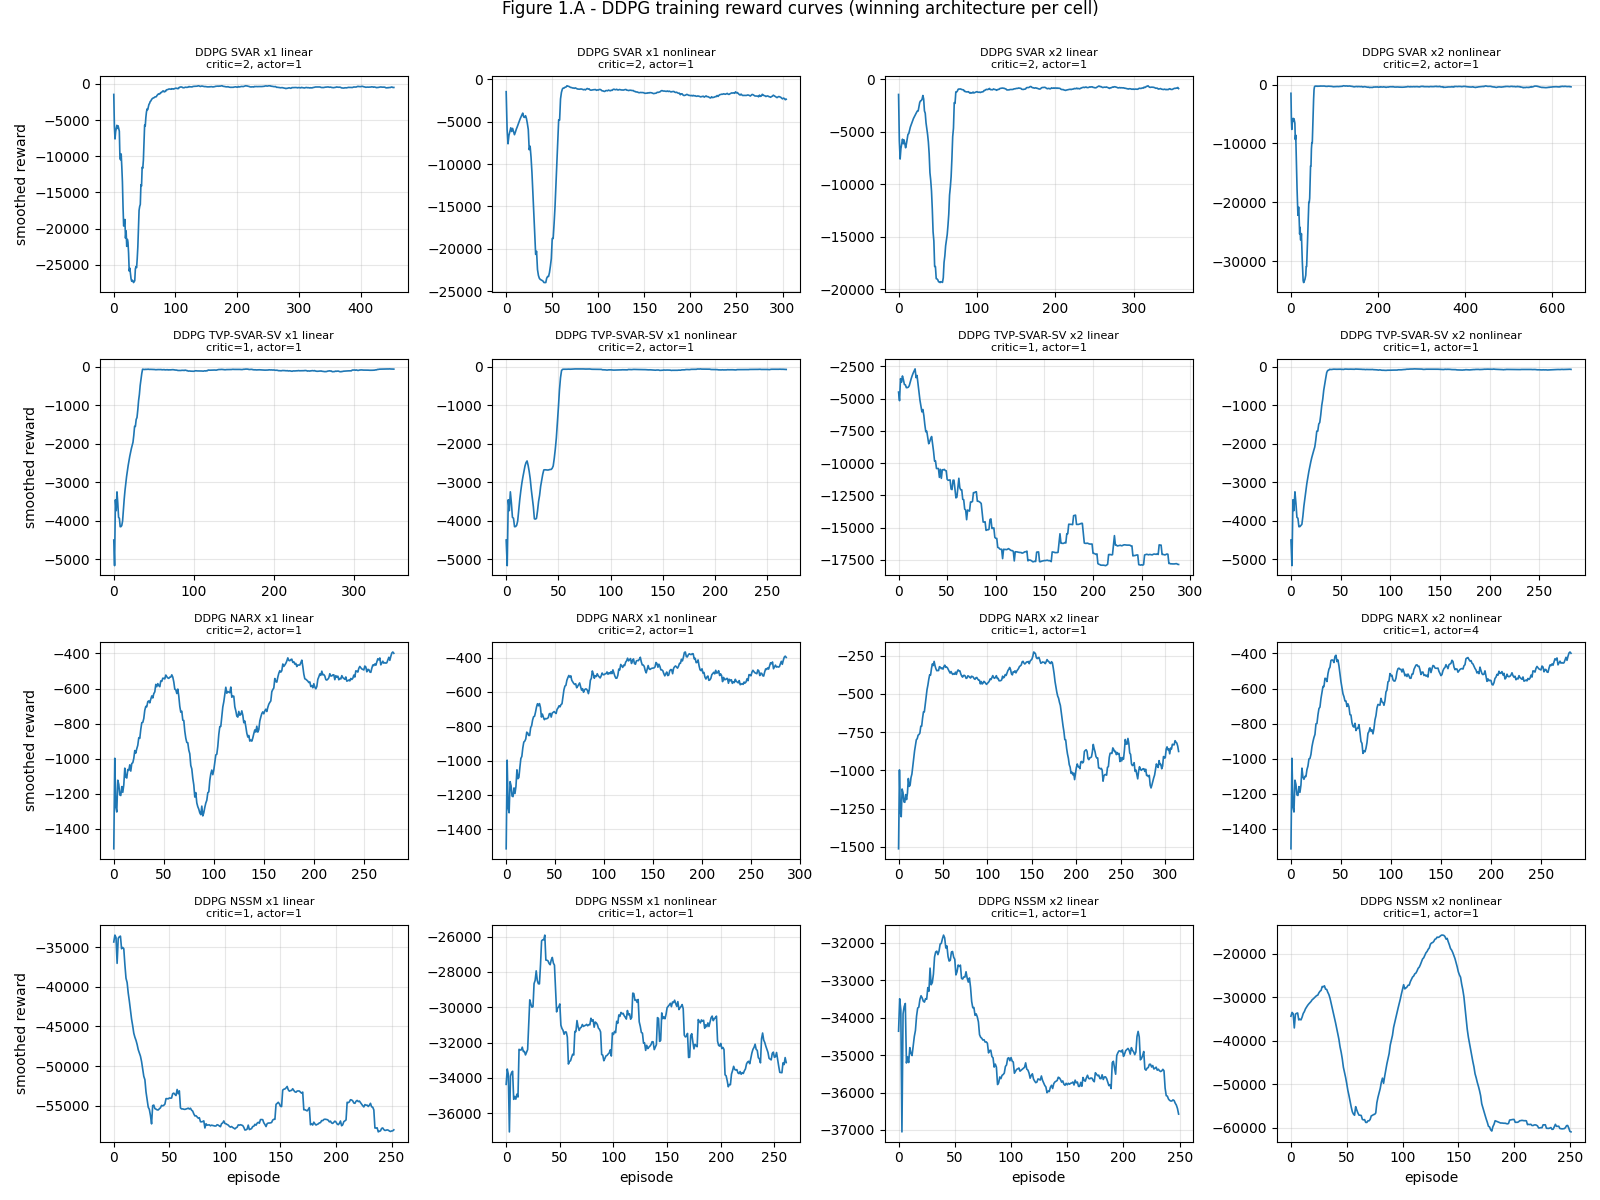

In [20]:
_n_envs = len(ENV_NAMES)
fig, axes = plt.subplots(_n_envs, 4, figsize=(16, 3 * _n_envs), sharex=False)
if _n_envs == 1:
    axes = np.array([axes])
for row, env_name in enumerate(ENV_NAMES):
    col = 0
    for obs_spec in OBS_SPECS:
        for policy_variant in POLICY_VARIANTS:
            key = ("DDPG", env_name, obs_spec, policy_variant)
            ax = axes[row, col]
            if key in trained_cells:
                cell = trained_cells[key]
                curve = pd.Series(cell.training_rewards).rolling(25, min_periods=1).mean()
                ax.plot(curve.values, lw=1.2)
                ax.set_title(f"DDPG {env_name} {obs_spec} {policy_variant}\n"
                             f"critic={cell.critic_nodes}, actor={cell.actor_nodes}",
                             fontsize=8)
            ax.grid(alpha=0.3)
            if row == _n_envs - 1: ax.set_xlabel("episode")
            if col == 0: ax.set_ylabel("smoothed reward")
            col += 1
fig.suptitle("Figure 1.A - DDPG training reward curves (winning architecture per cell)", y=1.0)
fig.tight_layout(); plt.show()


## Figures 1.B-1.E - DDPG policy surfaces

2x2 contour grids over $(\pi, y)$. Rows are observation specs (x1, x2); columns are policy
variants (linear, nonlinear). One figure per environment.


DDPG: built 16 counterfactual paths


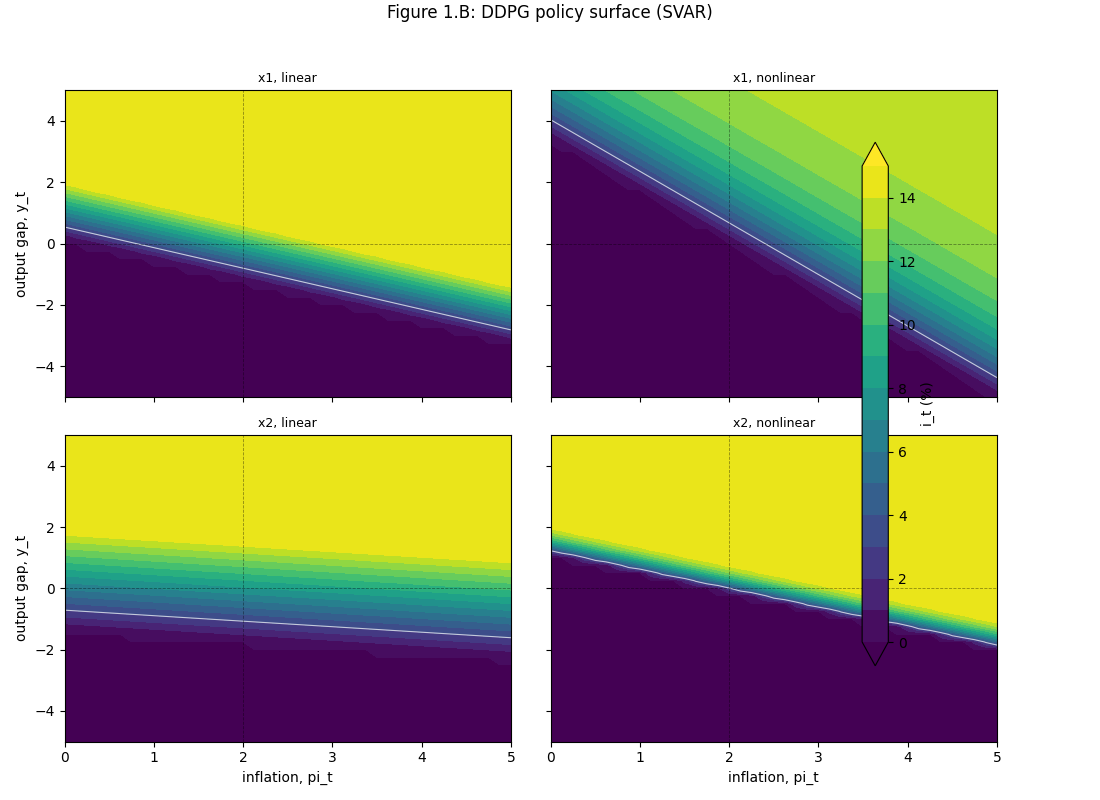

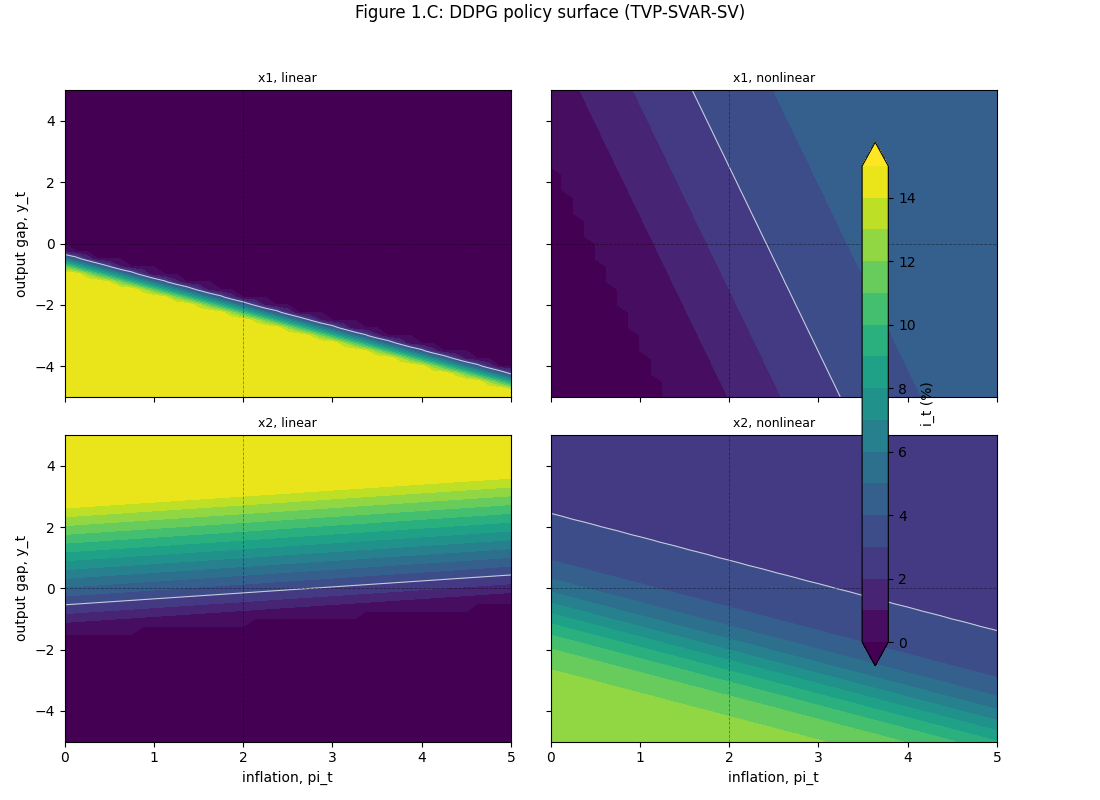

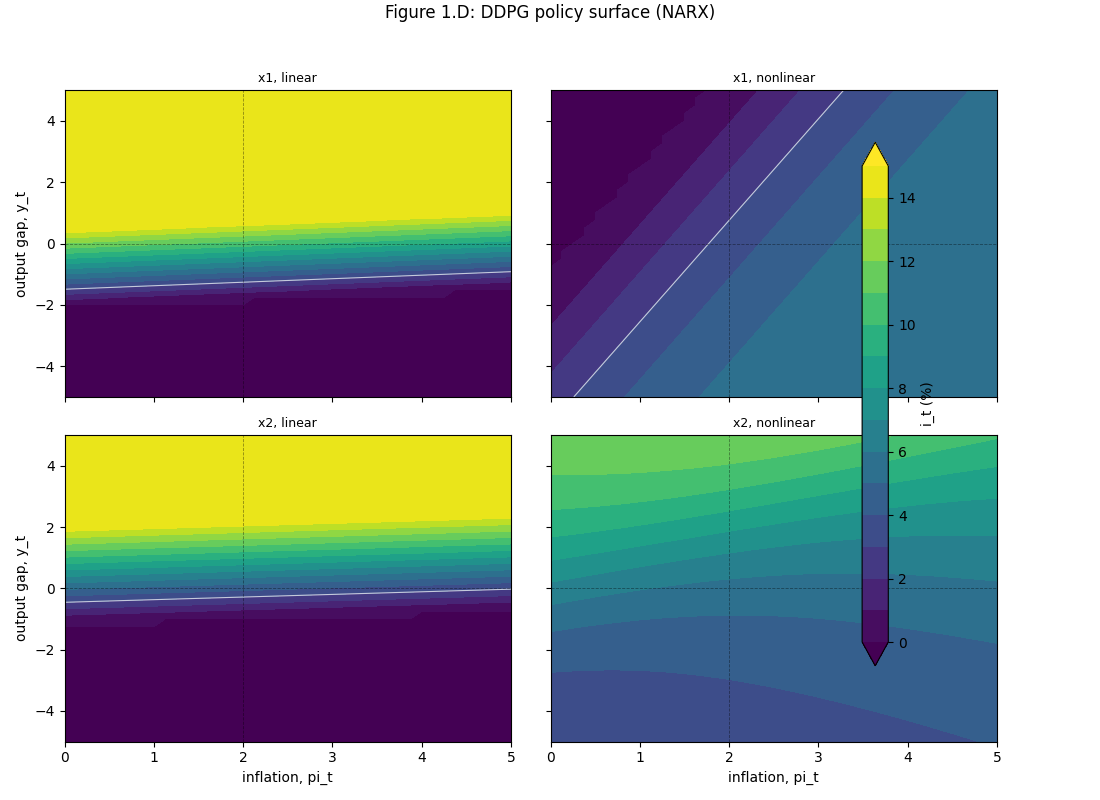

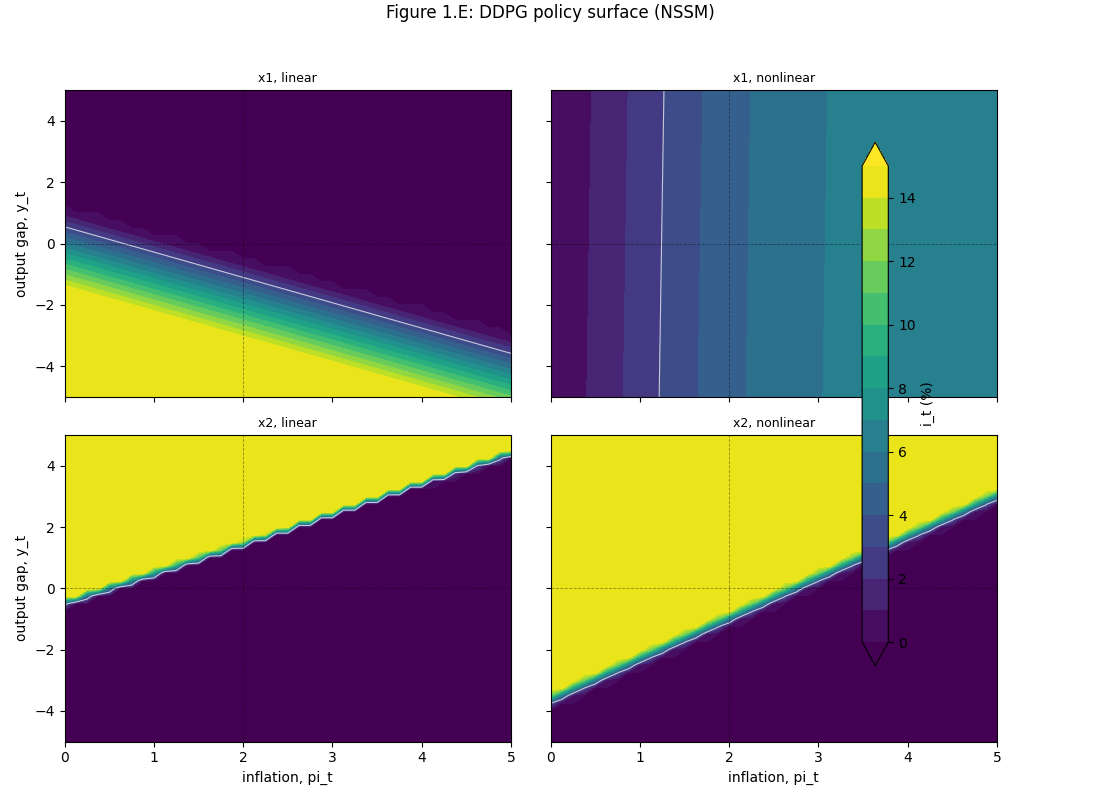

In [21]:
run_algo_counterfactuals("DDPG")
for env_name, fig_label in zip(ENV_NAMES, ["Figure 1.B", "Figure 1.C", "Figure 1.D", "Figure 1.E"]):
    plot_policy_surfaces_for_algo("DDPG", env_name, fig_label)


## Figures 1.F-1.I - DDPG counterfactual time series

DDPG-trained policies vs the three reference rules under each environment, replayed from the
empirical initial state. y-axes are clipped to readable bands; divergent paths are annotated
in the subtitle.


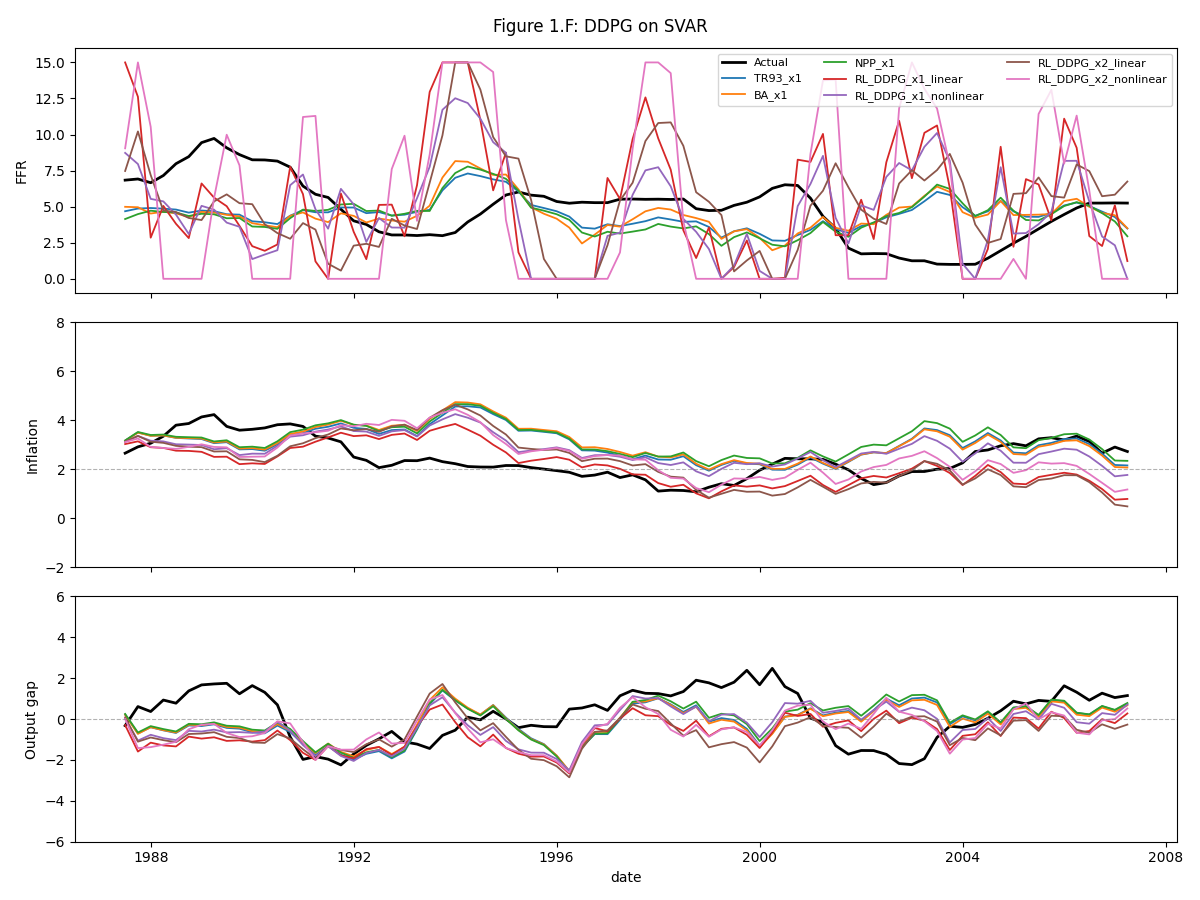

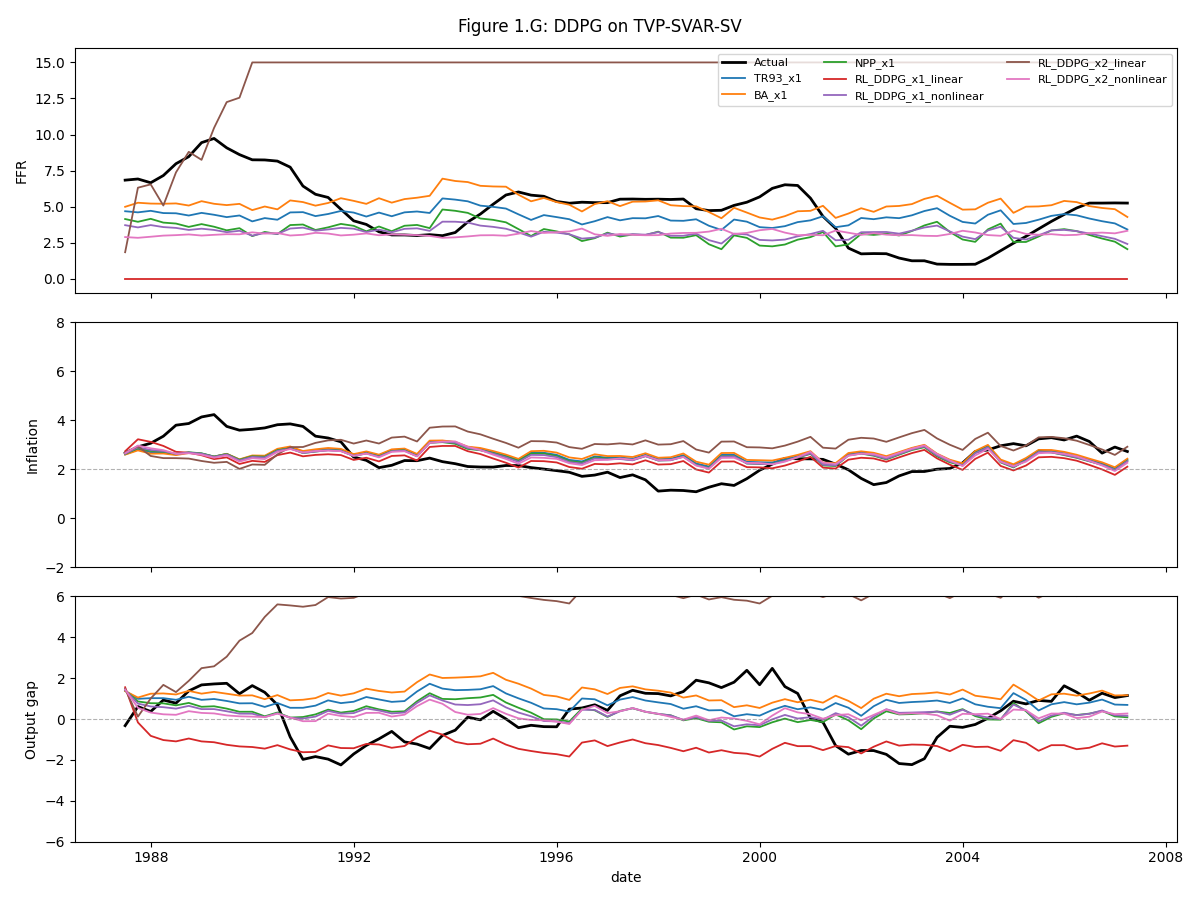

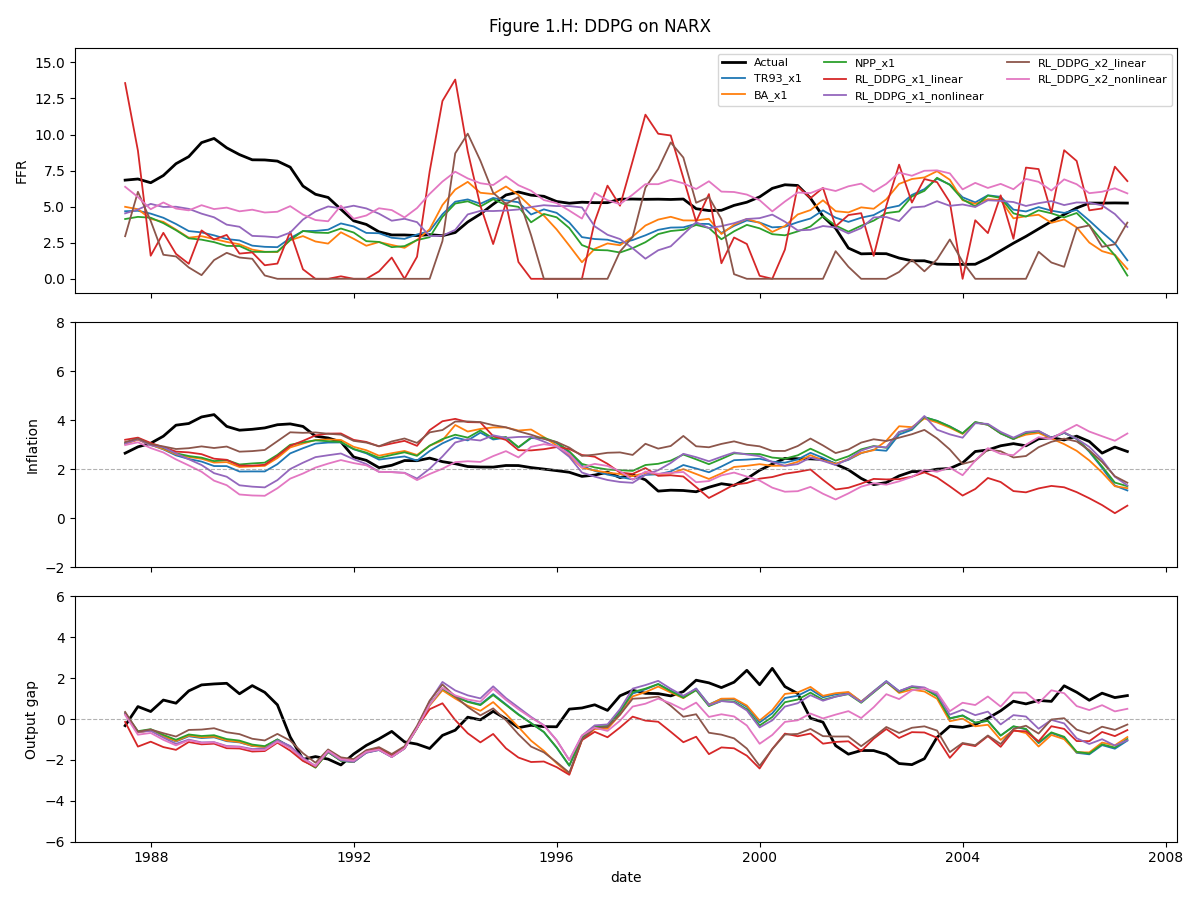

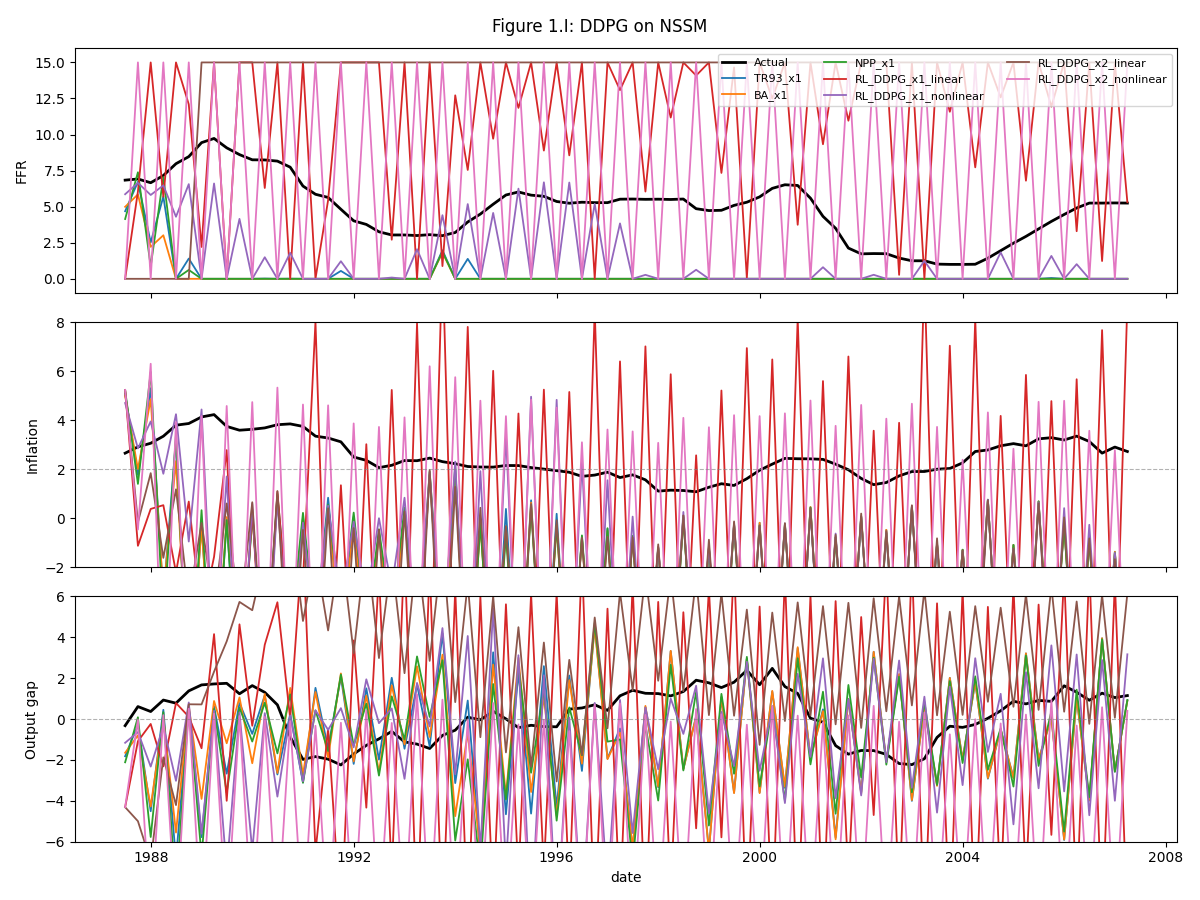

In [22]:
for env_name, fig_label in zip(ENV_NAMES,
                                ["Figure 1.F", "Figure 1.G", "Figure 1.H", "Figure 1.I"]):
    plot_counterfactual_panels_for_algo("DDPG", env_name, f"{fig_label}: DDPG on {env_name}")


## Counterfactual loss decomposition (DDPG)

The per-environment loss table reports $\mathrm{dev}^2_\pi$, $\mathrm{dev}^2_y$,
$\mathrm{dev}^2_{\Delta i}$, and the combined Loss for every DDPG cell and the three reference
rules.


In [23]:
actual_pi_arr = df["pi"].to_numpy()
actual_y_arr = df["y"].to_numpy()
actual_i_arr = df["i"].to_numpy()
actual_loss = loss_decomposition(actual_pi_arr, actual_y_arr, actual_i_arr)

for env_name in ENV_NAMES:
    print(f"\nCounterfactual loss decomposition (DDPG) under the {env_name} economy")
    rows = [{"Policy": "Actual FFR", **{k: round(v, 3) for k, v in actual_loss.items()}}]
    for (env_k, policy_label), paths in counterfactual_paths.items():
        if env_k != env_name: continue
        if not (policy_label.startswith("RL_DDPG_") or any(policy_label.startswith(r + "_") for r in REFERENCE_RULES)):
            continue
        rows.append({"Policy": policy_label,
                     **{k: round(v, 3) for k, v in loss_decomposition(paths["pi"], paths["y"], paths["i"]).items()}})
    print(pd.DataFrame(rows).to_string(index=False))



Counterfactual loss decomposition (DDPG) under the SVAR economy
              Policy  dev2_pi  dev2_y  dev2_di   Loss
          Actual FFR    0.849   1.621    0.222  1.346
             TR93_x1    1.523   0.787    0.176  1.243
               BA_x1    1.658   0.712    0.353  1.362
              NPP_x1    1.826   0.794    0.274  1.447
             TR93_x2    1.523   0.787    0.176  1.243
               BA_x2    1.658   0.712    0.353  1.362
              NPP_x2    1.826   0.794    0.274  1.447
   RL_DDPG_x1_linear    0.682   1.008   13.215  7.453
RL_DDPG_x1_nonlinear    1.002   0.842    4.959  3.401
   RL_DDPG_x2_linear    1.142   1.054    3.334  2.764
RL_DDPG_x2_nonlinear    1.025   0.886   22.717 12.314

Counterfactual loss decomposition (DDPG) under the TVP-SVAR-SV economy
              Policy  dev2_pi  dev2_y  dev2_di   Loss
          Actual FFR    0.849   1.621    0.222  1.346
             TR93_x1    0.395   0.780    0.097  0.636
               BA_x1    0.438   1.703    0.123  1.132

# SAC (Soft Actor-Critic)

SAC (Haarnoja et al., 2018) is an off-policy stochastic-actor algorithm with an automatically
tuned entropy coefficient. The stochastic squashed-Gaussian policy is not naturally compatible
with H&T's linear-policy variant, so we train a single nonlinear architecture per (env, obs spec)
cell with the default `MlpPolicy` of `net_arch=[64, 64]`. The same agent-selection callback
captures candidate checkpoints during training.

## SAC training loop


In [24]:
def train_sac_cell(env_name: str, obs_spec: str) -> TrainedCell:
    obs_lag = obs_spec_to_lag(obs_spec)
    env_factory = lambda: make_env(env_name, observation_lag=obs_lag, seed=SEED)
    init = initial_state_from_data()
    env = env_factory()
    model = SAC(
        "MlpPolicy", env,
        policy_kwargs=dict(net_arch=[64, 64]),
        learning_starts=500, batch_size=64,
        tau=0.005, gamma=GAMMA, ent_coef="auto",
        verbose=0, seed=SEED,
    )
    callback = HTAgentSelectionCallback()
    model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callback, progress_bar=False)
    _, ss_reward = select_best_candidate(model, callback.candidates, env_factory, init_state=init)
    return TrainedCell(
        algo="SAC", env_name=env_name, obs_spec=obs_spec, policy_variant="nonlinear",
        critic_nodes=64, actor_nodes=64, steady_state_reward=ss_reward,
        model=model, training_rewards=list(callback.episode_rewards),
    )


print("=" * 72)
print("SAC: training with H&T (2021) agent selection")
print("=" * 72)
for env_name in ENV_NAMES:
    for obs_spec in OBS_SPECS:
        key = ("SAC", env_name, obs_spec, "nonlinear")
        print(f"\n[SAC] env={env_name}  obs={obs_spec}")
        cell = train_sac_cell(env_name, obs_spec)
        trained_cells[key] = cell
        print(f"  >> SS reward = {cell.steady_state_reward:.4f}")

SAC: training with H&T (2021) agent selection

[SAC] env=SVAR  obs=x1
  >> SS reward = -9.6613

[SAC] env=SVAR  obs=x2
  >> SS reward = -9.9016

[SAC] env=TVP-SVAR-SV  obs=x1
  >> SS reward = -0.8749

[SAC] env=TVP-SVAR-SV  obs=x2
  >> SS reward = -0.8024

[SAC] env=NARX  obs=x1
  >> SS reward = -4.7112

[SAC] env=NARX  obs=x2
  >> SS reward = -5.5375

[SAC] env=NSSM  obs=x1
  >> SS reward = -inf

[SAC] env=NSSM  obs=x2
  >> SS reward = -71.2167


## Table 4 (SAC): linearised policy coefficients

SAC's stochastic policy is non-linear by construction, so the OLS approximation is reported
with its R^2 as a measure of how well a Taylor-rule form fits the trained policy.


In [25]:
sac_table4_rows = []
for env_name in ENV_NAMES:
    for obs_spec in OBS_SPECS:
        cell = trained_cells.get(("SAC", env_name, obs_spec, "nonlinear"))
        if cell is None: continue
        sac_table4_rows.append({"Policy": f"RL_SAC_{env_name}_{obs_spec}_nonlinear",
                                **linearise_policy(cell)})
sac_table4_df = pd.DataFrame(sac_table4_rows)
print("Table 4 (SAC): effective Taylor coefficients")
print(sac_table4_df.round(3).to_string(index=False))


Table 4 (SAC): effective Taylor coefficients
                         Policy  alpha0  beta_pi_0  beta_y_0    R2
       RL_SAC_SVAR_x1_nonlinear   7.009      0.851     2.363 0.855
       RL_SAC_SVAR_x2_nonlinear   7.847      0.336     2.505 0.856
RL_SAC_TVP-SVAR-SV_x1_nonlinear   2.519     -0.535     0.237 0.601
RL_SAC_TVP-SVAR-SV_x2_nonlinear   4.294     -1.033     1.134 0.785
       RL_SAC_NARX_x1_nonlinear   7.177     -0.414     0.062 0.937
       RL_SAC_NARX_x2_nonlinear   5.097     -0.796     1.707 0.828
       RL_SAC_NSSM_x1_nonlinear   0.345     -0.049    -0.043 0.305
       RL_SAC_NSSM_x2_nonlinear   1.995      1.208    -0.365 0.941


## Figure 2.A - SAC training reward curves


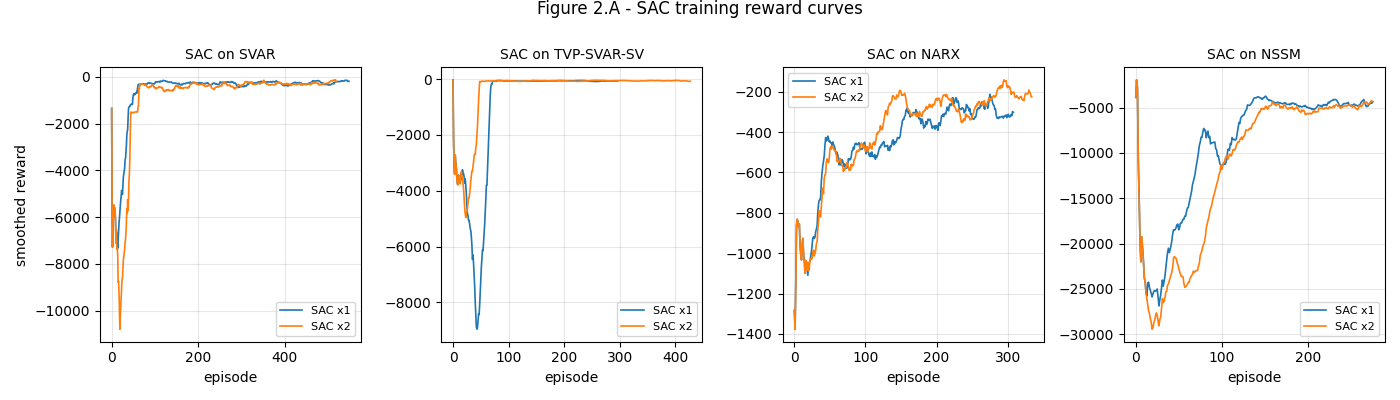

In [26]:
fig, axes = plt.subplots(1, _n_envs, figsize=(3.5 * _n_envs, 4), sharex=False)
if _n_envs == 1:
    axes = np.array([axes])
for j, env_name in enumerate(ENV_NAMES):
    ax = axes[j]
    sac_x1 = trained_cells.get(("SAC", env_name, "x1", "nonlinear"))
    sac_x2 = trained_cells.get(("SAC", env_name, "x2", "nonlinear"))
    if sac_x1 is not None:
        ax.plot(pd.Series(sac_x1.training_rewards).rolling(25, min_periods=1).mean().values,
                lw=1.2, label="SAC x1")
    if sac_x2 is not None:
        ax.plot(pd.Series(sac_x2.training_rewards).rolling(25, min_periods=1).mean().values,
                lw=1.2, label="SAC x2")
    ax.set_title(f"SAC on {env_name}", fontsize=10)
    ax.set_xlabel("episode"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
    if j == 0: ax.set_ylabel("smoothed reward")
fig.suptitle("Figure 2.A - SAC training reward curves", y=1.0)
fig.tight_layout(); plt.show()


## Figures 2.B-2.E - SAC policy surfaces


SAC: built 8 counterfactual paths


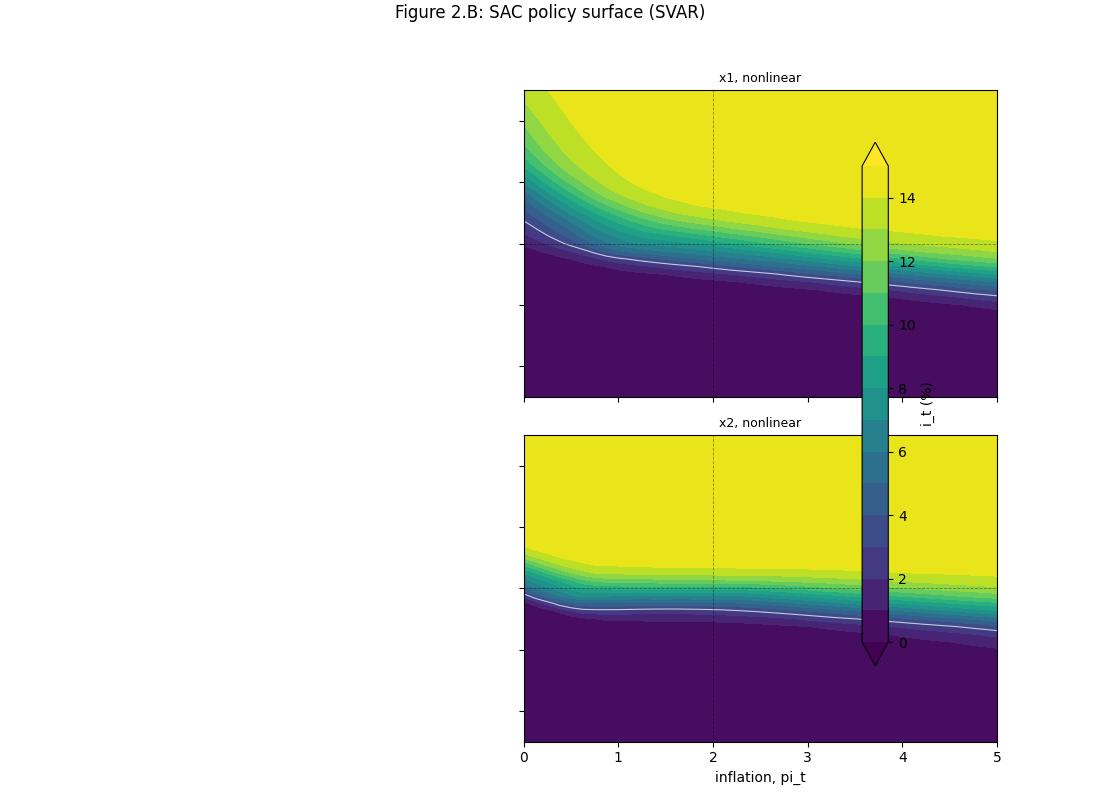

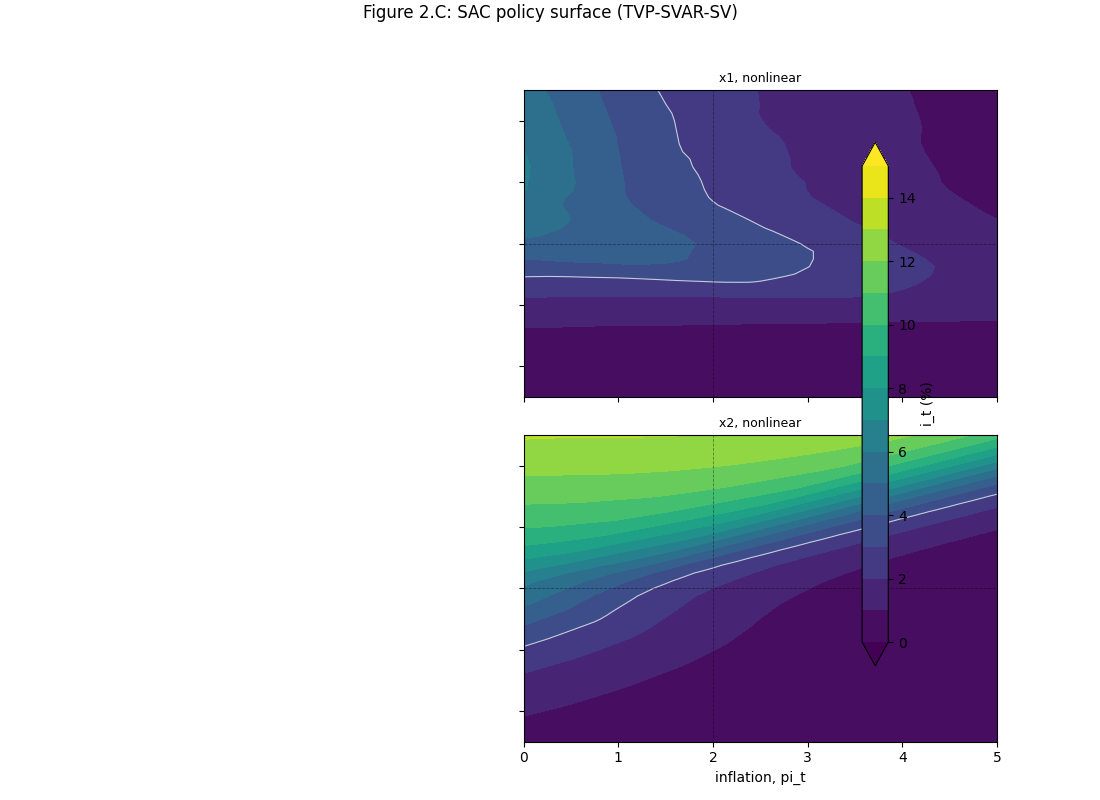

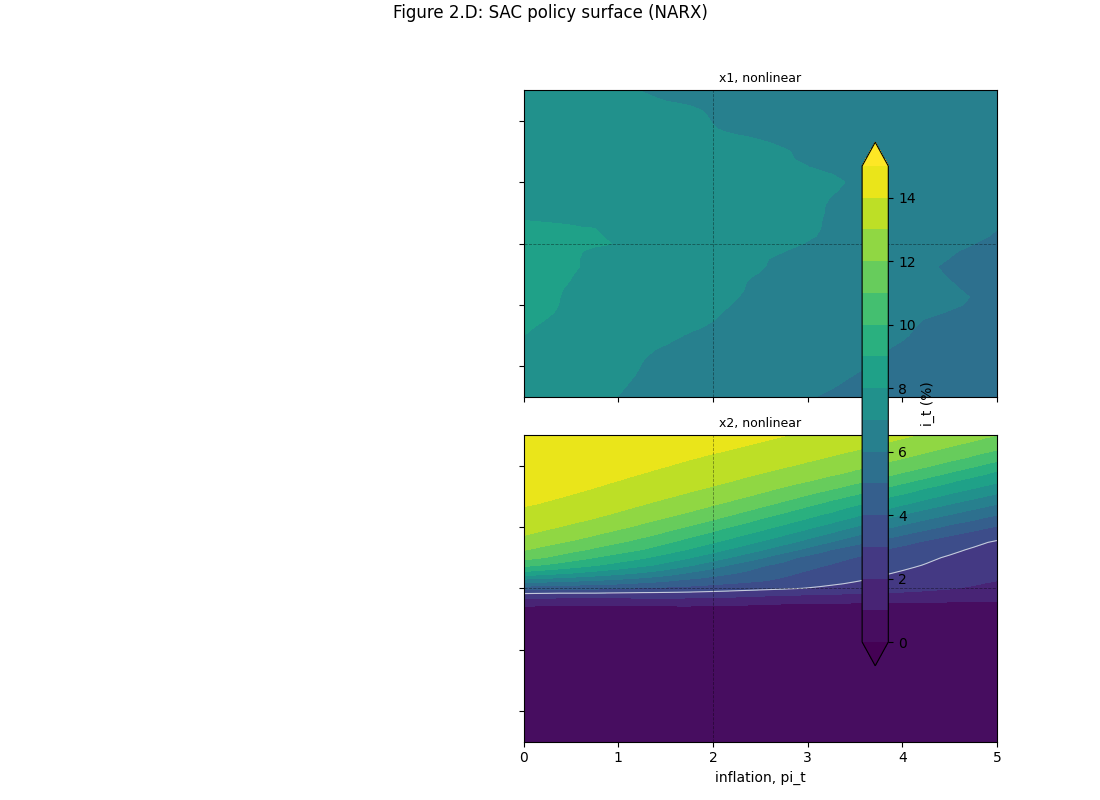

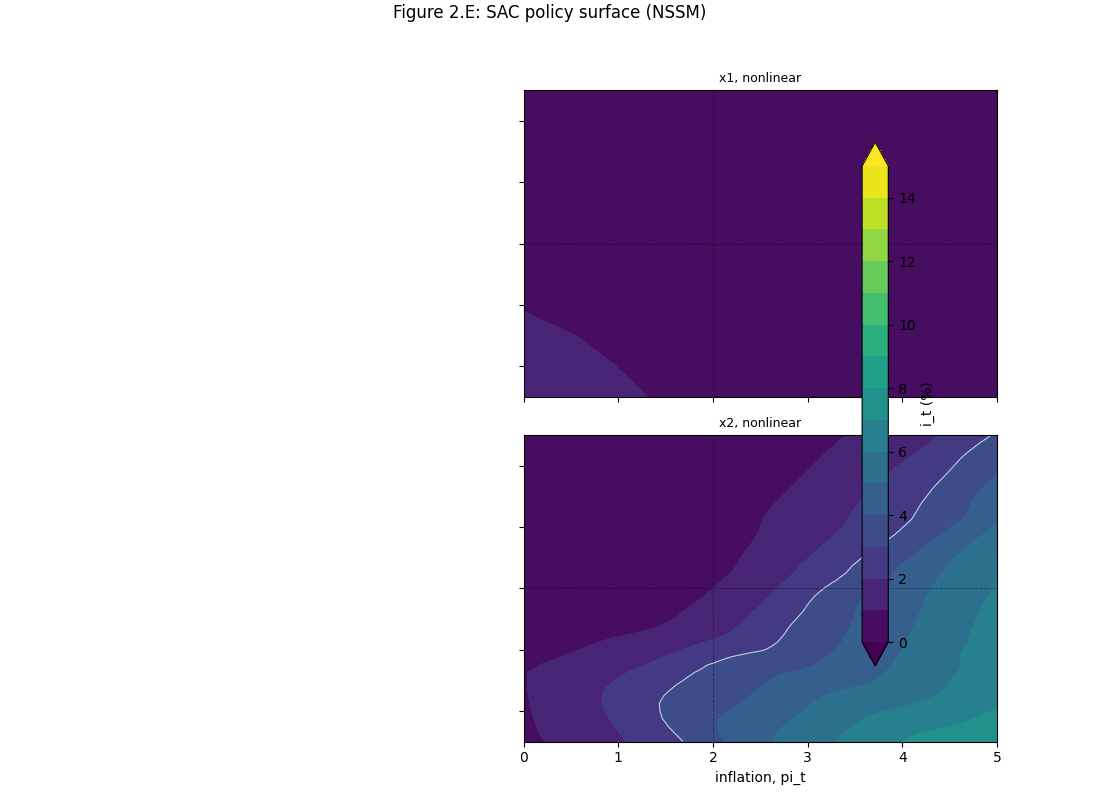

In [27]:
run_algo_counterfactuals("SAC")
for env_name, fig_label in zip(ENV_NAMES, ["Figure 2.B", "Figure 2.C", "Figure 2.D", "Figure 2.E"]):
    plot_policy_surfaces_for_algo("SAC", env_name, fig_label)


## Figures 2.F-2.I - SAC counterfactual time series


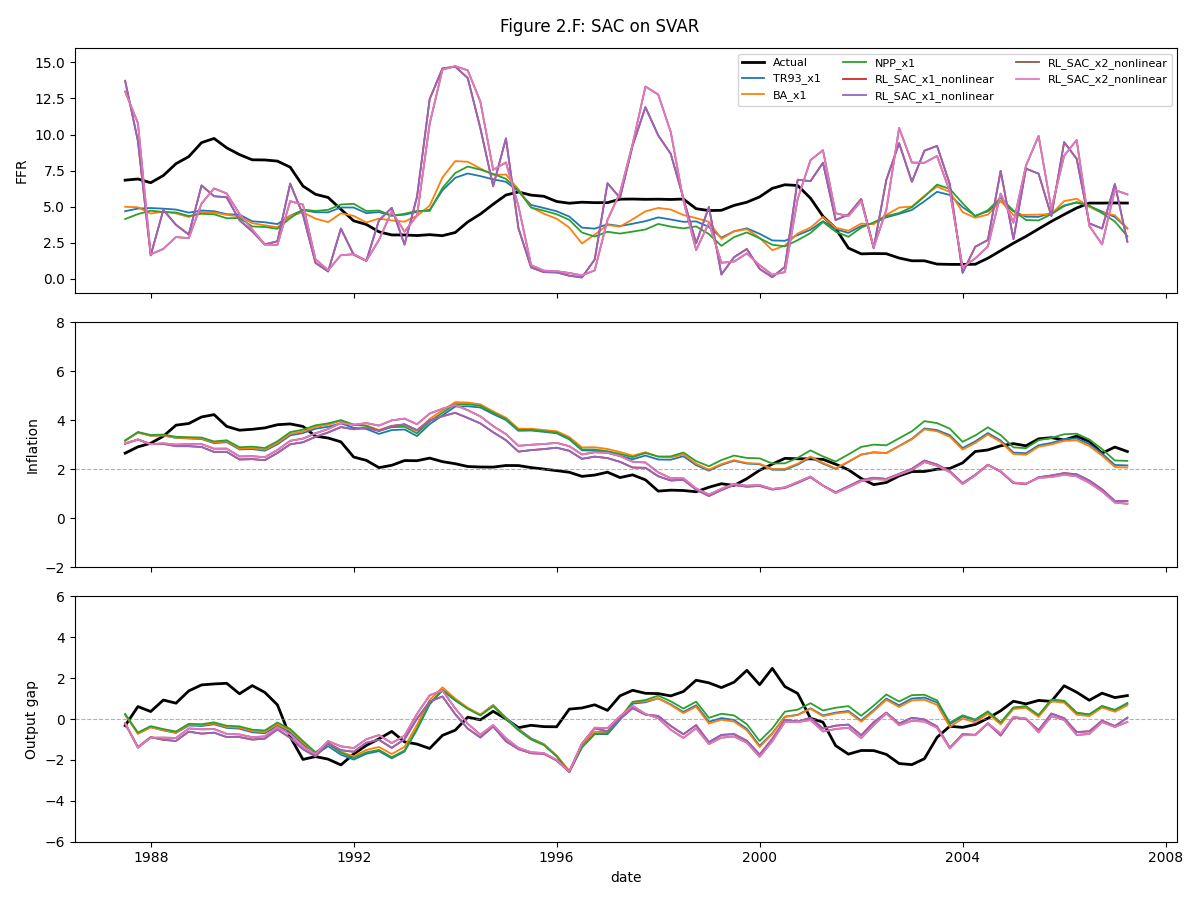

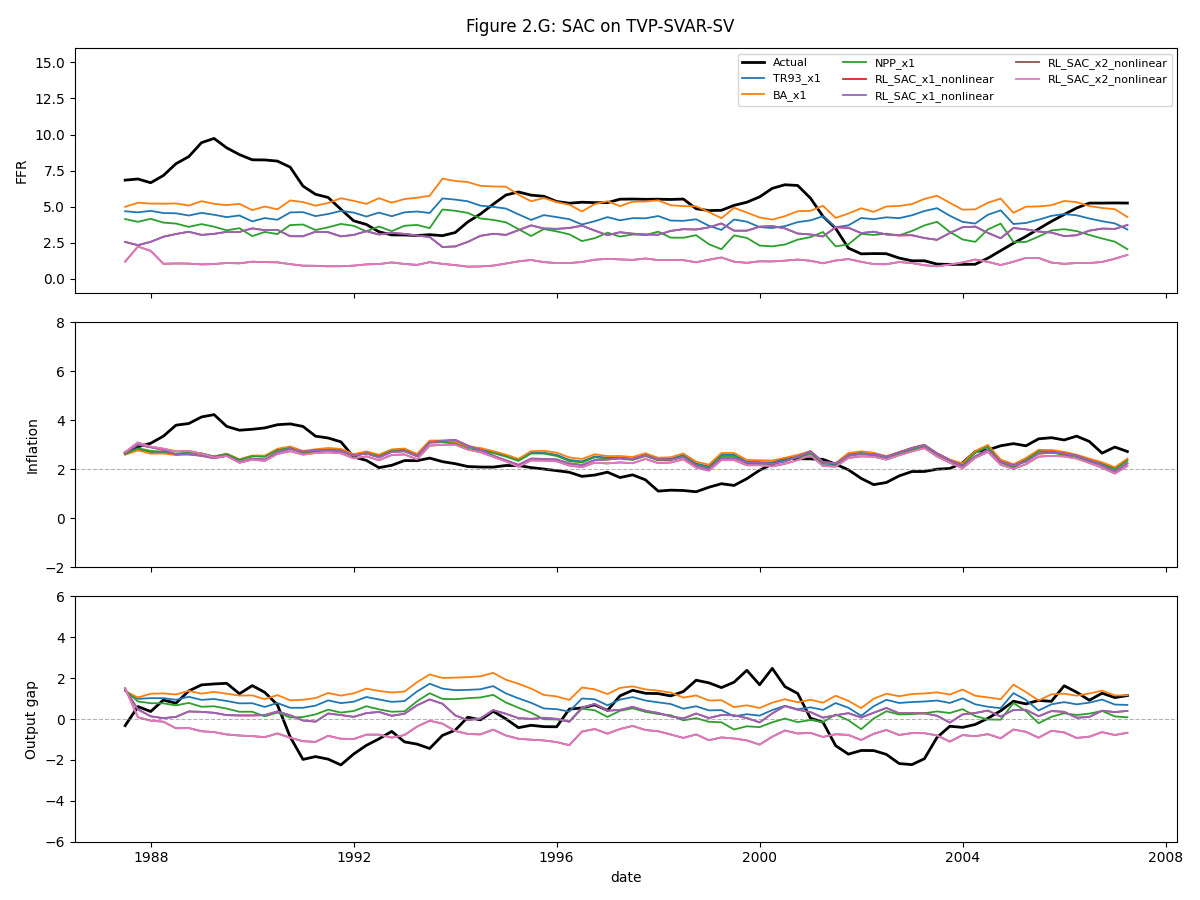

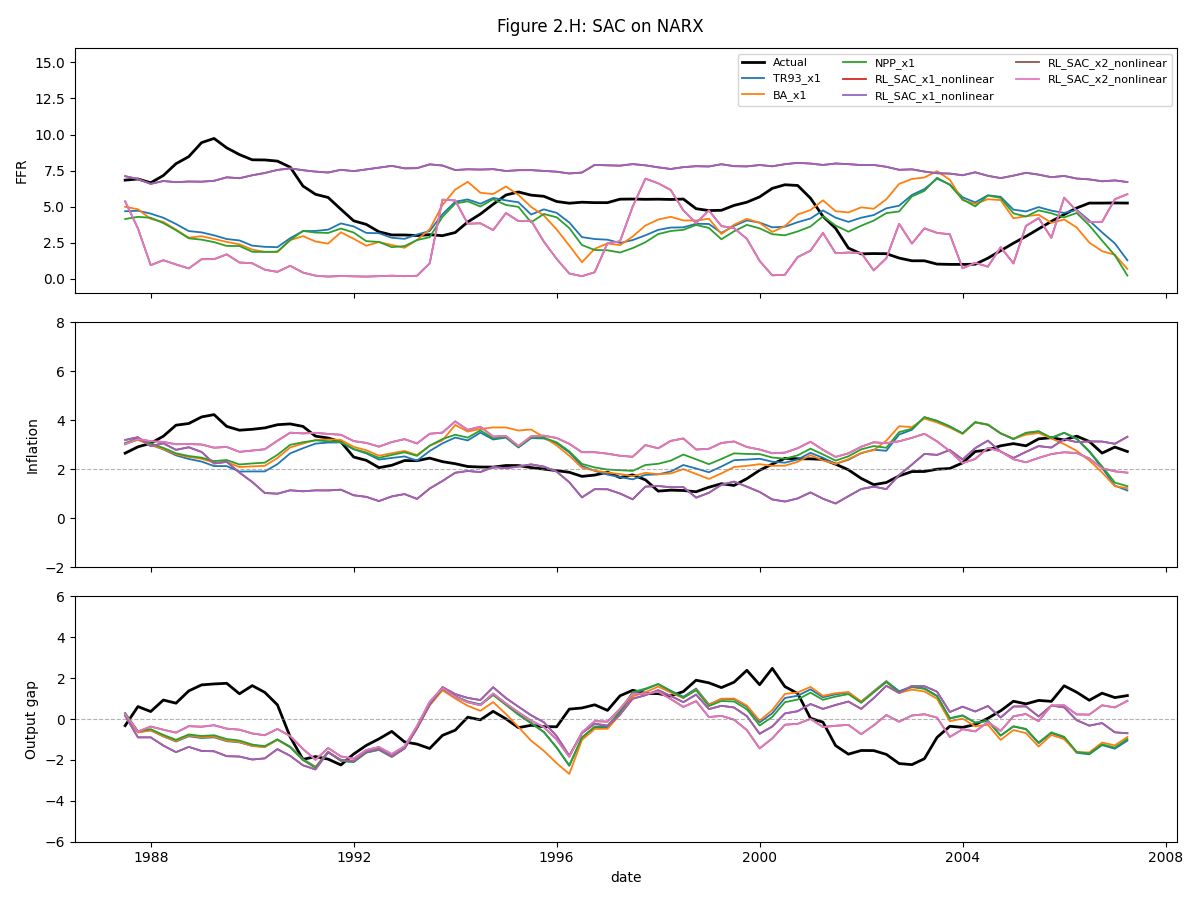

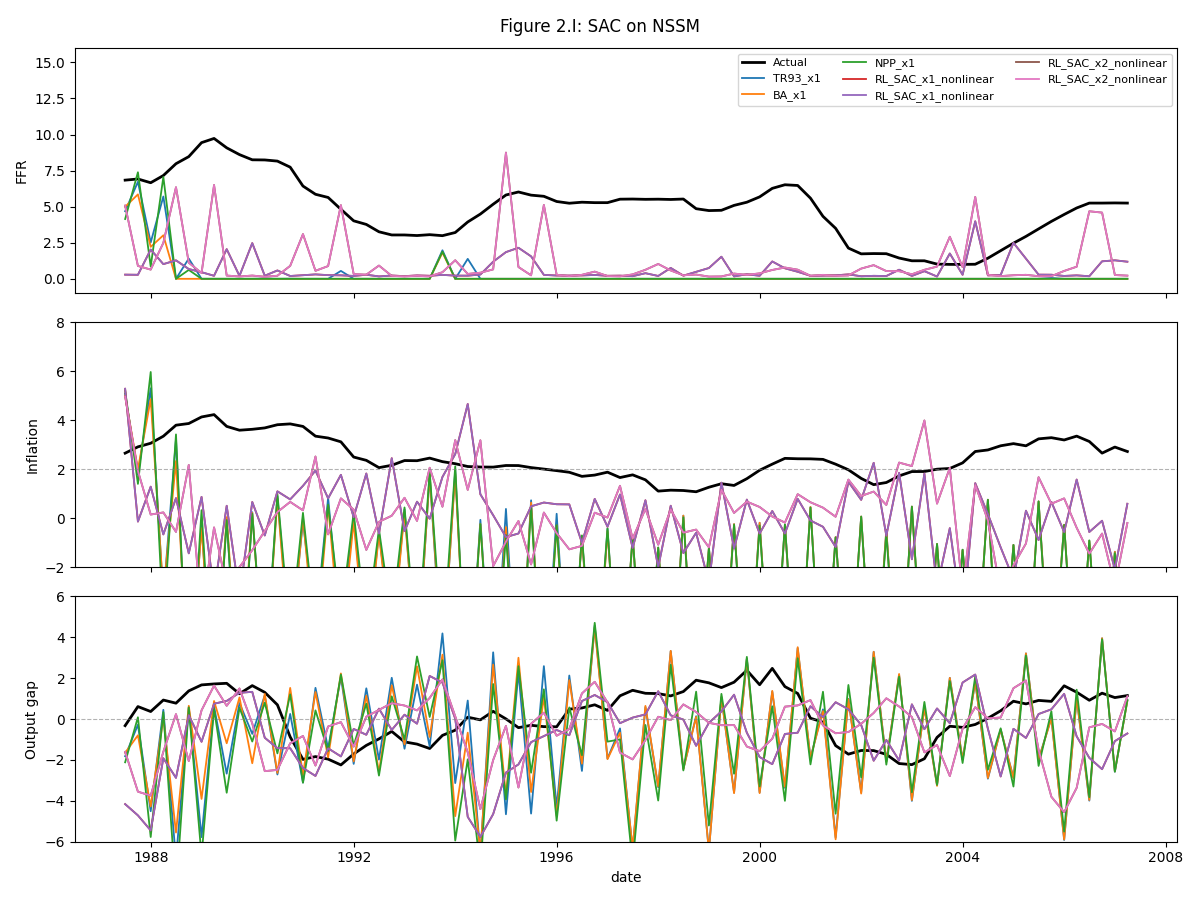

In [28]:
for env_name, fig_label in zip(ENV_NAMES,
                                ["Figure 2.F", "Figure 2.G", "Figure 2.H", "Figure 2.I"]):
    plot_counterfactual_panels_for_algo("SAC", env_name, f"{fig_label}: SAC on {env_name}")


## Counterfactual loss decomposition (SAC)


In [29]:
for env_name in ENV_NAMES:
    print(f"\nCounterfactual loss decomposition (SAC) under the {env_name} economy")
    rows = [{"Policy": "Actual FFR", **{k: round(v, 3) for k, v in actual_loss.items()}}]
    for (env_k, policy_label), paths in counterfactual_paths.items():
        if env_k != env_name: continue
        if not (policy_label.startswith("RL_SAC_") or any(policy_label.startswith(r + "_") for r in REFERENCE_RULES)):
            continue
        rows.append({"Policy": policy_label,
                     **{k: round(v, 3) for k, v in loss_decomposition(paths["pi"], paths["y"], paths["i"]).items()}})
    print(pd.DataFrame(rows).to_string(index=False))



Counterfactual loss decomposition (SAC) under the SVAR economy
             Policy  dev2_pi  dev2_y  dev2_di  Loss
         Actual FFR    0.849   1.621    0.222 1.346
            TR93_x1    1.523   0.787    0.176 1.243
              BA_x1    1.658   0.712    0.353 1.362
             NPP_x1    1.826   0.794    0.274 1.447
            TR93_x2    1.523   0.787    0.176 1.243
              BA_x2    1.658   0.712    0.353 1.362
             NPP_x2    1.826   0.794    0.274 1.447
RL_SAC_x1_nonlinear    0.990   0.847    9.243 5.540
RL_SAC_x2_nonlinear    1.236   0.818    7.752 4.903

Counterfactual loss decomposition (SAC) under the TVP-SVAR-SV economy
             Policy  dev2_pi  dev2_y  dev2_di  Loss
         Actual FFR    0.849   1.621    0.222 1.346
            TR93_x1    0.395   0.780    0.097 0.636
              BA_x1    0.438   1.703    0.123 1.132
             NPP_x1    0.348   0.261    0.170 0.389
            TR93_x2    0.395   0.780    0.097 0.636
              BA_x2    0.438   1.

# DSGE robustness exercise (Rudebusch-Svensson 1999)

## Methodology

Hinterlang & Tanzer (2021, Section 3.4 and Table 7) evaluate their optimised reaction functions
on 11 DSGE models from the Macroeconomic Model Database (Wieland et al., 2012, 2016) and report
the unconditional variances of inflation, the output gap, and the change in the policy rate
*relative to* the Taylor (1993) rule under each model. The exercise is a robustness check: a
policy rule that is optimised for one estimated economy (the SVAR or the ANN) is not guaranteed
to perform well in other plausible structural representations, and the DSGE comparison establishes
that the RL-optimised rules remain reasonably robust across models.

A full replication requires solving forward-looking rational-expectations DSGE models with Sims's
(2002) `gensys` or an equivalent (the Macroeconomic Model Database is built on `dynare`). Our
notebook does not embed `dynare`, so a strict replication of all 11 H&T models is out of scope.
We instead implement the *backward-looking* subset of the H&T robustness exercise, which Sims's
`gensys` reduces to a closed-form solve. The canonical backward-looking benchmark in the monetary-
policy literature is Rudebusch & Svensson (1999, henceforth RS99), which H&T cite explicitly. We
compute the unconditional variance of each variable under the closed-loop dynamics induced by
each candidate policy rule and report the variances relative to the Taylor (1993) baseline.

This section evaluates the DDPG and SAC policies from sections 1-2. Q-learning is added in
Section 4 (its own section) and the combined Table 7 in Section 5 includes all algorithms.

## Rudebusch-Svensson (1999) closed-form solver

The RS99 model is

$$\begin{aligned}
y_t &= 1.1597 y_{t-1} - 0.2588 y_{t-2} - 0.0908 (i_{t-1} - \bar{\pi}_{t-1}) + \varepsilon_t^y, \\
\pi_t &= 0.701 \pi_{t-1} + 0.3 \pi_{t-2} - 0.1 \pi_{t-3} + 0.1 \pi_{t-4} + 0.1397 y_{t-1} + \varepsilon_t^\pi, \\
\bar{\pi}_{t-1} &= \tfrac{1}{4}(\pi_{t-1} + \pi_{t-2} + \pi_{t-3} + \pi_{t-4}),
\end{aligned}$$

with shock standard deviations $\sigma_y = 0.819$ and $\sigma_\pi = 1.013$. We adopt the H&T
policy rule format with one lag,

$$i_t = \alpha_0 + \beta_\pi^0 (\pi_t - \pi^*) + \beta_\pi^1 (\pi_{t-1} - \pi^*) + \beta_y^0 y_t + \beta_y^1 y_{t-1},$$

stack the system in the state $z_t = (y_t, y_{t-1}, \pi_t, \pi_{t-1}, \pi_{t-2}, \pi_{t-3})$,
substitute the policy rule, and solve for the closed-loop $F(K)$ such that
$z_{t+1} = F(K) z_t + \eta_{t+1}$. The unconditional state-covariance matrix is the unique
stable solution of the discrete-time Lyapunov equation $V = FVF^\top + \Sigma$, which we compute
via `scipy.linalg.solve_discrete_lyapunov`.


In [30]:
def build_rs99_F(coeffs: Dict[str, float]) -> np.ndarray:
    """Closed-loop F matrix for RS99 under the H&T (eq. 17) policy rule.

    State z = [y_t, y_{t-1}, pi_t, pi_{t-1}, pi_{t-2}, pi_{t-3}] (6-dim).
    """
    c_pi0 = coeffs.get("beta_pi_0", 0.0)
    c_pi1 = coeffs.get("beta_pi_1", 0.0)
    c_y0 = coeffs.get("beta_y_0", 0.0)
    c_y1 = coeffs.get("beta_y_1", 0.0)

    # y_{t+1} coefficients on z
    # y_{t+1} = 1.1597 y_t - 0.2588 y_{t-1} - 0.0908 (i_t - pi_bar_t) + eps_y
    # i_t = c_pi0 pi_t + c_pi1 pi_{t-1} + c_y0 y_t + c_y1 y_{t-1}
    # pi_bar_t = (pi_t + pi_{t-1} + pi_{t-2} + pi_{t-3}) / 4
    f00 = 1.1597 - 0.0908 * c_y0
    f01 = -0.2588 - 0.0908 * c_y1
    f02 = -0.0908 * c_pi0 + 0.0908 / 4.0
    f03 = -0.0908 * c_pi1 + 0.0908 / 4.0
    f04 = 0.0908 / 4.0
    f05 = 0.0908 / 4.0

    F = np.array([
        [f00,  f01,  f02,  f03,  f04,  f05],   # y_{t+1}
        [1.0,  0.0,  0.0,  0.0,  0.0,  0.0],   # y_t (now lag-1)
        [0.1397, 0.0, 0.701, 0.3, -0.1, 0.1],  # pi_{t+1}
        [0.0,  0.0,  1.0,  0.0,  0.0,  0.0],   # pi_t (now lag-1)
        [0.0,  0.0,  0.0,  1.0,  0.0,  0.0],   # pi_{t-1} -> pi_{t-2}
        [0.0,  0.0,  0.0,  0.0,  1.0,  0.0],   # pi_{t-2} -> pi_{t-3}
    ])
    return F


RS99_SIGMA_Y = 0.819
RS99_SIGMA_PI = 1.013
RS99_SHOCK_COV = np.diag([RS99_SIGMA_Y ** 2, 0.0, RS99_SIGMA_PI ** 2, 0.0, 0.0, 0.0])


def rs99_variances(coeffs: Dict[str, float]) -> Optional[Dict[str, float]]:
    """Compute (var(pi), var(y), var(Delta i)) under the given policy rule.

    Returns None if the closed loop is unstable (any |eig(F)| >= 1).
    """
    F = build_rs99_F(coeffs)
    eig = np.linalg.eigvals(F)
    if np.max(np.abs(eig)) >= 1.0 - 1e-10:
        return None
    V = scipy.linalg.solve_discrete_lyapunov(F, RS99_SHOCK_COV)
    var_y = float(V[0, 0])
    var_pi = float(V[2, 2])
    # var(Delta i) = K (2V - F V - V F^T) K^T
    K = np.array([
        coeffs.get("beta_y_0", 0.0),
        coeffs.get("beta_y_1", 0.0),
        coeffs.get("beta_pi_0", 0.0),
        coeffs.get("beta_pi_1", 0.0),
        0.0, 0.0,
    ])
    cov_diff = 2.0 * V - F @ V - V @ F.T
    var_di = float(K @ cov_diff @ K)
    return {"var_pi": var_pi, "var_y": var_y, "var_di": max(var_di, 0.0)}

## Policy coefficient collection (DDPG + SAC)

For each trained DDPG cell we use `linearise_policy` (OLS approximation, accounts for action-
space clipping). For SAC cells we use the same linearisation. The reference rules are entered
by hand from Hinterlang & Tanzer (2021, Table 4).


In [31]:
def dsge_coeffs_for_cell(cell: TrainedCell) -> Dict[str, float]:
    """Return policy coefficients in H&T eq. 17 form, with one lag."""
    coefs = linearise_policy(cell)
    return {
        "beta_pi_0": coefs.get("beta_pi_0", 0.0),
        "beta_pi_1": coefs.get("beta_pi_1", 0.0),
        "beta_y_0":  coefs.get("beta_y_0",  0.0),
        "beta_y_1":  coefs.get("beta_y_1",  0.0),
    }


policy_coeffs_dsge = {
    "TR93": {"beta_pi_0": 1.5, "beta_pi_1": 0.0, "beta_y_0": 0.5, "beta_y_1": 0.0},
    "BA":   {"beta_pi_0": 1.5, "beta_pi_1": 0.0, "beta_y_0": 1.0, "beta_y_1": 0.0},
    "NPP":  {"beta_pi_0": 2.0, "beta_pi_1": 0.0, "beta_y_0": 0.5, "beta_y_1": 0.0},
}
for (algo, env_name, obs_spec, policy_variant), cell in trained_cells.items():
    if algo not in ("DDPG", "SAC"):
        continue
    label = f"RL_{algo}_{env_name}_{obs_spec}_{policy_variant if policy_variant else 'none'}"
    policy_coeffs_dsge[label] = dsge_coeffs_for_cell(cell)

print(f"Collected policy coefficients for {len(policy_coeffs_dsge)} policies (DDPG + SAC + reference)")


Collected policy coefficients for 27 policies (DDPG + SAC + reference)


## Table 7 (DDPG + SAC): RS99 relative variances

Values less than 1 indicate the candidate rule reduces the corresponding variance below the
Taylor (1993) baseline; values greater than 1 indicate higher variance; `inf` indicates that the
closed-loop system is unstable (Taylor principle violated).


In [32]:
dsge_results = {}
for label, coeffs in policy_coeffs_dsge.items():
    res = rs99_variances(coeffs)
    if res is None:
        dsge_results[label] = {"var_pi": np.inf, "var_y": np.inf, "var_di": np.inf, "stable": False}
    else:
        dsge_results[label] = {**res, "stable": True}

tr93_res = dsge_results["TR93"]
rows = []
for label, r in dsge_results.items():
    if not r["stable"]:
        rows.append({"Policy": label, "var(pi)/TR93": np.inf, "var(y)/TR93": np.inf,
                     "var(Delta i)/TR93": np.inf, "Mean": np.inf})
        continue
    ratio_pi = r["var_pi"] / max(tr93_res["var_pi"], 1e-12)
    ratio_y  = r["var_y"]  / max(tr93_res["var_y"],  1e-12)
    ratio_di = r["var_di"] / max(tr93_res["var_di"], 1e-12)
    rows.append({"Policy": label, "var(pi)/TR93": ratio_pi, "var(y)/TR93": ratio_y,
                 "var(Delta i)/TR93": ratio_di, "Mean": (ratio_pi + ratio_y + ratio_di) / 3.0})

dsge_table7_ddpgsac_df = pd.DataFrame(rows).round(3)
print("Table 7 (DDPG + SAC + reference rules): RS99 closed-loop variances, ratios to TR93")
print("Lower is better; inf = unstable closed loop.")
print(dsge_table7_ddpgsac_df.to_string(index=False))


NameError: name 'scipy' is not defined

## Figure 3.A - RS99 closed-loop variance scatter (DDPG + SAC)

Reference rules and stable RL rules in the $(\mathrm{var}(\pi), \mathrm{var}(y))$ plane,
normalised by TR93. Dominated rules sit to the upper-right of TR93; Pareto-efficient ones
reduce at least one variance without increasing the other.


In [ ]:
finite_rows = [r for r in rows if np.isfinite(r["Mean"])]
labels = [r["Policy"] for r in finite_rows]
ratio_pi = np.array([r["var(pi)/TR93"] for r in finite_rows])
ratio_y  = np.array([r["var(y)/TR93"]  for r in finite_rows])
is_ref = np.array([lab in REFERENCE_RULES or lab == "TR93" for lab in labels])
is_rl = ~is_ref

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(ratio_pi[is_ref], ratio_y[is_ref], s=140, c="black", marker="s", label="Reference rules")
ax.scatter(ratio_pi[is_rl],  ratio_y[is_rl],  s=80,  c="C0", alpha=0.7, label="RL rules (DDPG/SAC)")
for k in np.where(is_ref)[0]:
    ax.annotate(labels[k], (ratio_pi[k], ratio_y[k]), xytext=(5, 5),
                textcoords="offset points", fontsize=9)
ax.axhline(1.0, color="grey", ls="--", lw=0.8, alpha=0.5)
ax.axvline(1.0, color="grey", ls="--", lw=0.8, alpha=0.5)
ax.set_xlabel("var(inflation) / TR93")
ax.set_ylabel("var(output gap) / TR93")
ax.set_title("Figure 3.A - RS99 closed-loop variance ratios (DDPG + SAC)")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

print("\nBest RL rules by mean ratio:")
for r in sorted(finite_rows, key=lambda r: r["Mean"])[:5]:
    if r["Policy"] in REFERENCE_RULES or r["Policy"] == "TR93":
        continue
    print(f"  {r['Policy']:<55} Mean={r['Mean']:.3f}")


# Tabular Q-learning

Stable-Baselines3 does not ship a tabular Q-learning agent. We implement Watkins's (1989)
algorithm directly; Wang et al. (2026) report that on similar single-CB monetary MDPs tabular
Q-learning outperforms DQN and Bayesian variants. The state space is discretised to a 6 x 7 grid
over $(y, \pi)$ and the action grid is 21 points in $[0, 10]$, so the table is small enough to
train in seconds. We restrict to the no-lag observation specification $x_t^{(1)}$ throughout.

## QLearningAgent class


In [ ]:
@dataclass
class QLearningAgent:
    obs_low: np.ndarray
    obs_high: np.ndarray
    n_bins: Tuple[int, int]
    action_grid: np.ndarray
    Q: np.ndarray
    alpha: float = 0.2
    gamma: float = GAMMA
    epsilon: float = 0.2
    rng: np.random.Generator = field(default_factory=lambda: np.random.default_rng(SEED))

    @classmethod
    def build(cls, *, n_bins: Tuple[int, int] = (6, 7),
              action_grid: Sequence[float] = tuple(np.arange(0.0, 10.5, 0.5)),
              obs_low: Optional[np.ndarray] = None,
              obs_high: Optional[np.ndarray] = None,
              alpha: float = 0.2, epsilon: float = 0.2,
              seed: int = SEED) -> "QLearningAgent":
        if obs_low is None:
            obs_low = np.array([-6.0, -2.0])
        if obs_high is None:
            obs_high = np.array([6.0, 6.0])
        return cls(
            obs_low=obs_low, obs_high=obs_high, n_bins=n_bins,
            action_grid=np.asarray(action_grid, dtype=np.float64),
            Q=np.zeros((*n_bins, len(action_grid)), dtype=np.float64),
            alpha=alpha, epsilon=epsilon, rng=np.random.default_rng(seed),
        )

    def discretise(self, obs: np.ndarray) -> Tuple[int, int]:
        idx = []
        for k in range(2):
            lo, hi = self.obs_low[k], self.obs_high[k]
            x = (float(obs[k]) - lo) / (hi - lo)
            b = int(np.clip(np.floor(x * self.n_bins[k]), 0, self.n_bins[k] - 1))
            idx.append(b)
        return tuple(idx)

    def action_index(self, value: float) -> int:
        return int(np.argmin(np.abs(self.action_grid - value)))

    def act(self, obs: np.ndarray, explore: bool = True) -> float:
        s = self.discretise(obs)
        if explore and self.rng.random() < self.epsilon:
            return float(self.rng.choice(self.action_grid))
        a_idx = int(np.argmax(self.Q[s]))
        return float(self.action_grid[a_idx])

    def update(self, obs, action, reward, next_obs, done):
        s = self.discretise(obs)
        s2 = self.discretise(next_obs)
        a_idx = self.action_index(action)
        target = reward + (0.0 if done else self.gamma * float(self.Q[s2].max()))
        self.Q[(*s, a_idx)] += self.alpha * (target - self.Q[(*s, a_idx)])

## Q-learning training loop


In [ ]:
def train_q_cell(env_name: str) -> TrainedCell:
    env = make_env(env_name, observation_lag=False, seed=SEED)
    agent = QLearningAgent.build(seed=SEED)
    rewards: List[float] = []
    for ep in range(Q_EPISODES):
        obs, _ = env.reset()
        total = 0.0
        for _ in range(T_MAX):
            i_val = agent.act(obs, explore=True)
            obs2, r, term, trunc, info = env.step(rate_to_normalised(i_val))
            agent.update(obs, i_val, r, obs2, term or trunc)
            total += float(r)
            obs = obs2
            if term or trunc:
                break
        agent.epsilon = max(0.02, agent.epsilon * 0.999)
        rewards.append(total)
    return TrainedCell(
        algo="Q-learning", env_name=env_name, obs_spec="x1", policy_variant=None,
        critic_nodes=None, actor_nodes=None,
        steady_state_reward=float(np.mean(rewards[-200:])),
        model=agent, training_rewards=rewards,
    )


print("=" * 72)
print("Tabular Q-learning")
print("=" * 72)
for env_name in ENV_NAMES:
    key = ("Q-learning", env_name, "x1", None)
    print(f"\n[Q-learning] env={env_name}")
    cell = train_q_cell(env_name)
    trained_cells[key] = cell
    print(f"  >> mean reward (last 200 episodes) = {cell.steady_state_reward:.4f}")

## Table 4 (Q-learning): linearised policy coefficients

Q-learning's discretised policy is non-linear and non-differentiable; the OLS R^2 measures how
well a Taylor-rule form fits the discretised reaction function over the grid.


In [ ]:
q_table4_rows = []
for env_name in ENV_NAMES:
    cell = trained_cells.get(("Q-learning", env_name, "x1", None))
    if cell is None: continue
    q_table4_rows.append({"Policy": f"RL_Qlearning_{env_name}_x1_none",
                          **linearise_policy(cell)})
q_table4_df = pd.DataFrame(q_table4_rows)
print("Table 4 (Q-learning): effective Taylor coefficients")
print(q_table4_df.round(3).to_string(index=False))


## Figure 4.A - Q-learning training reward curves


In [ ]:
fig, axes = plt.subplots(1, _n_envs, figsize=(3.5 * _n_envs, 4), sharex=False)
if _n_envs == 1:
    axes = np.array([axes])
for j, env_name in enumerate(ENV_NAMES):
    ax = axes[j]
    q_cell = trained_cells.get(("Q-learning", env_name, "x1", None))
    if q_cell is not None:
        ax.plot(pd.Series(q_cell.training_rewards).rolling(100, min_periods=1).mean().values, lw=1.2)
    ax.set_title(f"Q-learning on {env_name}", fontsize=10)
    ax.set_xlabel("episode"); ax.grid(alpha=0.3)
    if j == 0: ax.set_ylabel("smoothed reward")
fig.suptitle("Figure 4.A - Q-learning training reward curves", y=1.0)
fig.tight_layout(); plt.show()


## Figures 4.B-4.E - Q-learning policy surfaces

Q-learning trains on $x_t^{(1)}$ only (no lag) for tractability, so only the upper-left tile
of each environment's 2x2 grid is populated; the other three are intentionally blank.


In [ ]:
run_algo_counterfactuals("Q-learning")
for env_name, fig_label in zip(ENV_NAMES, ["Figure 4.B", "Figure 4.C", "Figure 4.D", "Figure 4.E"]):
    plot_policy_surfaces_for_algo("Q-learning", env_name, fig_label)


## Figures 4.F-4.I - Q-learning counterfactual time series


In [ ]:
for env_name, fig_label in zip(ENV_NAMES,
                                ["Figure 4.F", "Figure 4.G", "Figure 4.H", "Figure 4.I"]):
    plot_counterfactual_panels_for_algo("Q-learning", env_name,
                                         f"{fig_label}: Q-learning on {env_name}")


## Counterfactual loss decomposition (Q-learning)


In [ ]:
for env_name in ENV_NAMES:
    print(f"\nCounterfactual loss decomposition (Q-learning) under the {env_name} economy")
    rows_q = [{"Policy": "Actual FFR", **{k: round(v, 3) for k, v in actual_loss.items()}}]
    for (env_k, policy_label), paths in counterfactual_paths.items():
        if env_k != env_name: continue
        if not (policy_label.startswith("RL_Q-learning_") or
                any(policy_label.startswith(r + "_") for r in REFERENCE_RULES)):
            continue
        rows_q.append({"Policy": policy_label,
                       **{k: round(v, 3) for k, v in loss_decomposition(paths["pi"], paths["y"], paths["i"]).items()}})
    print(pd.DataFrame(rows_q).to_string(index=False))


# Combined results across algorithms

This section overlays results from DDPG, SAC, and Q-learning side-by-side. The reference rules
(TR93, BA, NPP) appear in every panel as black baselines.

## Combined Table 4 (effective Taylor coefficients, all algorithms)


In [ ]:
combined_table4 = pd.concat([ddpg_table4_df, sac_table4_df, q_table4_df], ignore_index=True)
print("Combined Table 4: effective Taylor coefficients across all algorithms")
print(combined_table4.round(3).to_string(index=False))


## Combined counterfactual loss table (per environment, all algorithms)


In [ ]:
for env_name in ENV_NAMES:
    print(f"\nCombined counterfactual loss decomposition under the {env_name} economy")
    rows_c = [{"Policy": "Actual FFR", **{k: round(v, 3) for k, v in actual_loss.items()}}]
    for (env_k, policy_label), paths in counterfactual_paths.items():
        if env_k != env_name: continue
        rows_c.append({"Policy": policy_label,
                       **{k: round(v, 3) for k, v in loss_decomposition(paths["pi"], paths["y"], paths["i"]).items()}})
    print(pd.DataFrame(rows_c).to_string(index=False))


## Figures 5.A-5.D - Combined counterfactual time series

One figure per environment. Reference rules (TR93/BA/NPP) plus the best-of-class RL policy
from each algorithm overlaid against the actual data.


In [ ]:
def plot_combined_counterfactual(env_name, fig_label):
    """All algos overlaid for a single environment."""
    actual_i = df["i"].to_numpy()
    actual_pi_ = df["pi"].to_numpy()
    actual_y_ = df["y"].to_numpy()
    T_show = min(len(actual_i), T_CF)
    idx = pd.PeriodIndex(df.index[:T_show], freq="Q").to_timestamp()

    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
    axes[0].plot(idx, actual_i[:T_show], color="black", lw=2.0, label="Actual")
    axes[1].plot(idx, actual_pi_[:T_show], color="black", lw=2.0, label="Actual")
    axes[2].plot(idx, actual_y_[:T_show], color="black", lw=2.0, label="Actual")

    cmap = plt.get_cmap("tab10")
    # Reference rules in greys; algos in distinct colors
    palette = {
        "TR93_x1": ("0.3", "-", 1.0),
        "BA_x1":   ("0.5", "--", 1.0),
        "NPP_x1":  ("0.7", ":", 1.0),
    }
    for k, (label, (color, ls, lw)) in enumerate(palette.items()):
        paths = counterfactual_paths.get((env_name, label))
        if paths is None: continue
        axes[0].plot(idx, paths["i"][:T_show], color=color, lw=lw, ls=ls, label=label)
        axes[1].plot(idx, paths["pi"][:T_show], color=color, lw=lw, ls=ls, label=label)
        axes[2].plot(idx, paths["y"][:T_show], color=color, lw=lw, ls=ls, label=label)

    # One representative cell per algo (smallest dev2_pi+dev2_y on this env)
    for k, algo in enumerate(["DDPG", "SAC", "Q-learning"]):
        best_label, best_loss = None, np.inf
        for (env_k, policy_label), paths in counterfactual_paths.items():
            if env_k != env_name: continue
            if not policy_label.startswith(f"RL_{algo}_"): continue
            l = loss_decomposition(paths["pi"], paths["y"], paths["i"])["Loss"]
            if l < best_loss:
                best_loss = l; best_label = policy_label
        if best_label is None: continue
        paths = counterfactual_paths[(env_name, best_label)]
        color = cmap(k + 1)
        axes[0].plot(idx, paths["i"][:T_show], color=color, lw=1.4, label=f"{algo}: {best_label}")
        axes[1].plot(idx, paths["pi"][:T_show], color=color, lw=1.4, label=f"{algo}: {best_label}")
        axes[2].plot(idx, paths["y"][:T_show], color=color, lw=1.4, label=f"{algo}: {best_label}")

    axes[0].set_ylabel("FFR"); axes[0].set_ylim(-1.0, ACTION_HIGH + 1.0)
    axes[1].set_ylabel("Inflation"); axes[1].axhline(PI_STAR, color="grey", lw=0.8, ls="--", alpha=0.6)
    axes[2].set_ylabel("Output gap"); axes[2].axhline(0.0, color="grey", lw=0.8, ls="--", alpha=0.6)
    axes[1].set_ylim(-2.0, 8.0); axes[2].set_ylim(-6.0, 6.0)
    axes[2].set_xlabel("date")
    axes[0].legend(ncol=3, fontsize=8, loc="upper right")
    fig.suptitle(f"{fig_label}: best-of-class RL policies vs reference rules ({env_name})")
    fig.tight_layout(); plt.show()


for env_name, fig_label in zip(ENV_NAMES, ["Figure 5.A", "Figure 5.B", "Figure 5.C", "Figure 5.D"]):
    plot_combined_counterfactual(env_name, fig_label)


## Combined Table 7 (RS99 ranking, all algorithms)

Extends Section 3's Table 7 with Q-learning cells.


In [ ]:
# Re-collect coefficients including Q-learning
for (algo, env_name, obs_spec, policy_variant), cell in trained_cells.items():
    if algo != "Q-learning":
        continue
    label = f"RL_{algo}_{env_name}_{obs_spec}_none"
    policy_coeffs_dsge[label] = dsge_coeffs_for_cell(cell)

dsge_results_all = {}
for label, coeffs in policy_coeffs_dsge.items():
    res = rs99_variances(coeffs)
    if res is None:
        dsge_results_all[label] = {"var_pi": np.inf, "var_y": np.inf, "var_di": np.inf, "stable": False}
    else:
        dsge_results_all[label] = {**res, "stable": True}

tr93_res = dsge_results_all["TR93"]
rows_all = []
for label, r in dsge_results_all.items():
    if not r["stable"]:
        rows_all.append({"Policy": label, "var(pi)/TR93": np.inf, "var(y)/TR93": np.inf,
                          "var(Delta i)/TR93": np.inf, "Mean": np.inf})
        continue
    rp = r["var_pi"] / max(tr93_res["var_pi"], 1e-12)
    ry = r["var_y"]  / max(tr93_res["var_y"],  1e-12)
    rd = r["var_di"] / max(tr93_res["var_di"], 1e-12)
    rows_all.append({"Policy": label, "var(pi)/TR93": rp, "var(y)/TR93": ry,
                     "var(Delta i)/TR93": rd, "Mean": (rp + ry + rd) / 3.0})

combined_table7_df = pd.DataFrame(rows_all).round(3)
print("Combined Table 7: RS99 closed-loop variances, ratios to TR93 (all algorithms)")
print(combined_table7_df.to_string(index=False))

print("\nBest 10 stable RL rules by mean variance ratio:")
finite_rl = [r for r in rows_all if np.isfinite(r["Mean"]) and r["Policy"].startswith("RL_")]
for r in sorted(finite_rl, key=lambda r: r["Mean"])[:10]:
    print(f"  {r['Policy']:<55} Mean={r['Mean']:.3f}")


## Discussion and limitations

**Faithful to H&T (with documented departures):**
- All four economy environments use the parent notebooks' fitted models directly.
- The agent's action $i_t$ is correctly mapped to $i_{t-1}$ in the *next* period's transition equation.
- Linear and nonlinear actor variants implemented as `LinearActor` and `NonlinearActor` overrides
  of SB3's `TD3Actor`, with H&T eq. 12-13 semantics and no extraneous output `tanh` squash.
- Both observation specifications $x_t^{(1)}$ and $x_t^{(2)}$ trained for every applicable cell.
- Hidden-node search over critic and (nonlinear) actor nodes; agent selection by ER/ES filter
  followed by the steady-state-reward tie-break.

**Pragmatic deviations from H&T:**
- Default architecture grid is narrower than H&T's full $\{1, \ldots, 10\}$ ranges. Setting
  `FULL_GRID = True` in cell 0.5 recovers the full grid at an order-of-magnitude longer wall-clock.
- The TVP-SVAR-SV environment uses the smoother-based posterior mean at the training endpoint
  (2007Q2). Because the parent notebook fits the TVP on the full sample including out-of-sample
  data, this anchor incorporates a small amount of post-2007 information.
- The reward function adds a Sack-Wieland $(\Delta i)^2$ smoothing term (cf. H&T eq. 16 which
  omits it). This is needed because without it the agent learns a globally-optimal bang-bang
  policy. The smoothing term is standard in the optimal-monetary-policy literature.
- The agent-selection filter is loosened from ER/ES > -4 (H&T) to ER/ES > -50 during the
  search phase to accumulate candidates from the NSSM environment, which extrapolates badly.
  The steady-state-reward tiebreaker still picks the winner.
- A macro-state clamp at $\pm 10$ percentage points around steady state prevents runaway
  trajectories from dominating the agent-selection callback.

**DSGE exercise limitations:**
- We implement only the Rudebusch & Svensson (1999) backward-looking benchmark. The 10
  forward-looking models in H&T's exercise require solving rational-expectations equilibria
  via Sims's (2002) `gensys` or an equivalent, which we do not embed here. A full replication
  is a follow-on contribution.
- The nonlinear policies (DDPG nonlinear, SAC, Q-learning) are evaluated in the DSGE exercise
  using an OLS-linearised approximation of their reaction functions. This is consistent with
  how H&T evaluate their nonlinear ANN policies in Table 7 (the DSGE comparison requires linear
  feedback), but it discards the precise nonlinearities of the learned policies.


# 6. References


## 6.1 Software and libraries

Both parent notebooks install their own dependencies (`fedfred`, `PyMC`, `PyTensor`, `PyTorch`, `statsmodels`); this notebook additionally installs `Stable-Baselines3` (Raffin et al., 2021), `gymnasium` (Towers et al., 2023), and `tqdm`. The full list of versions used during development is given in the bibliography.


## 6.2 Papers and books

- Adam, K., & Billi, R. M. (2006). Optimal monetary policy under commitment with a zero bound on nominal interest rates. *Journal of Money, Credit and Banking*, 38(7), 1877-1905.
- Bellman, R. (1957). *Dynamic Programming*. Princeton University Press.
- Cogley, T., & Sargent, T. J. (2005). Drifts and volatilities: Monetary policies and outcomes in the post WWII US. *Review of Economic Dynamics*, 8(2), 262-302.
- Fraccaro, M., Sonderby, S. K., Paquet, U., & Winther, O. (2016). Sequential neural models with stochastic layers. In *Advances in Neural Information Processing Systems 29* (pp. 2199-2207).
- Giacomini, R., & White, H. (2006). Tests of conditional predictive ability. *Econometrica*, 74(6), 1545-1578.
- Glorot, X., & Bengio, Y. (2010). Understanding the difficulty of training deep feedforward neural networks. In *Proceedings of the 13th International Conference on Artificial Intelligence and Statistics* (pp. 249-256).
- Goodfriend, M. (2004). Inflation targeting in the United States? In B. S. Bernanke & M. Woodford (Eds.), *The Inflation-Targeting Debate* (pp. 311-352). University of Chicago Press.
- Haarnoja, T., Zhou, A., Abbeel, P., & Levine, S. (2018). Soft actor-critic: Off-policy maximum entropy deep reinforcement learning with a stochastic actor. In *Proceedings of the 35th International Conference on Machine Learning* (Vol. 80, pp. 1861-1870).
- Hawkins, R. J., Speakes, J. K., & Hamilton, D. E. (2015). Monetary policy and PID control. *Journal of Economic Interaction and Coordination*, 10(1), 183-197.
- Hinterlang, N., & Tanzer, A. (2021). Optimal monetary policy using reinforcement learning. *Deutsche Bundesbank Discussion Paper No. 51/2021*.
- Howard, R. A. (1960). *Dynamic Programming and Markov Processes*. MIT Press.
- Krishnan, R. G., Shalit, U., & Sontag, D. (2017). Structured inference networks for nonlinear state space models. In *Proceedings of the 31st AAAI Conference on Artificial Intelligence* (pp. 2101-2109).
- Levenberg, K. (1944). A method for the solution of certain non-linear problems in least squares. *Quarterly of Applied Mathematics*, 2(2), 164-168.
- Lillicrap, T. P., Hunt, J. J., Pritzel, A., Heess, N., Erez, T., Tassa, Y., Silver, D., & Wierstra, D. (2015). Continuous control with deep reinforcement learning. *arXiv preprint arXiv:1509.02971*.
- Lucas, R. E., Jr. (1976). Econometric policy evaluation: A critique. *Carnegie-Rochester Conference Series on Public Policy*, 1, 19-46.
- Marquardt, D. W. (1963). An algorithm for least-squares estimation of nonlinear parameters. *Journal of the Society for Industrial and Applied Mathematics*, 11(2), 431-441.
- Mnih, V., Kavukcuoglu, K., Silver, D., Graves, A., Antonoglou, I., Wierstra, D., & Riedmiller, M. (2013). Playing Atari with deep reinforcement learning. *arXiv preprint arXiv:1312.5602*.
- Mnih, V., Kavukcuoglu, K., Silver, D., Rusu, A. A., Veness, J., Bellemare, M. G., Graves, A., Riedmiller, M., Fidjeland, A. K., Ostrovski, G., Petersen, S., Beattie, C., Sadik, A., Antonoglou, I., King, H., Kumaran, D., Wierstra, D., Legg, S., & Hassabis, D. (2015). Human-level control through deep reinforcement learning. *Nature*, 518(7540), 529-533.
- Nair, V., & Hinton, G. E. (2010). Rectified linear units improve restricted Boltzmann machines. In *Proceedings of the 27th International Conference on Machine Learning* (pp. 807-814).
- Nguyen, D., & Widrow, B. (1990). Improving the learning speed of 2-layer neural networks by choosing initial values of the adaptive weights. In *International Joint Conference on Neural Networks* (Vol. 3, pp. 21-26).
- Nikolsko-Rzhevskyy, A., Papell, D. H., & Prodan, R. (2018). The Taylor principles. *Journal of Macroeconomics*, 55, 14-30.
- Orphanides, A., & Wieland, V. (2000). Inflation zone targeting. *European Economic Review*, 44(7), 1351-1387.
- Primiceri, G. E. (2005). Time varying structural vector autoregressions and monetary policy. *Review of Economic Studies*, 72(3), 821-852.
- Rangapuram, S. S., Seeger, M., Gasthaus, J., Stella, L., Wang, Y., & Januschowski, T. (2018). Deep state space models for time series forecasting. In *Advances in Neural Information Processing Systems 31* (pp. 7796-7805).
- Rotemberg, J. J., & Woodford, M. (1997). An optimization-based econometric framework for the evaluation of monetary policy. *NBER Macroeconomics Annual*, 12, 297-346.
- Rudebusch, G. D., & Svensson, L. E. O. (1999). Policy rules for inflation targeting. In J. B. Taylor (Ed.), *Monetary Policy Rules* (pp. 203-262). University of Chicago Press.
- Saxe, A. M., McClelland, J. L., & Ganguli, S. (2014). Exact solutions to the nonlinear dynamics of learning in deep linear neural networks. In *International Conference on Learning Representations*.
- Silver, D., Lever, G., Heess, N., Degris, T., Wierstra, D., & Riedmiller, M. (2014). Deterministic policy gradient algorithms. In *Proceedings of the 31st International Conference on Machine Learning* (pp. 387-395).
- Sims, C. A. (2002). Solving linear rational expectations models. *Computational Economics*, 20(1-2), 1-20.
- Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press.
- Svensson, L. E. O. (2020). Monetary policy strategies for the Federal Reserve. *International Journal of Central Banking*, 16(1), 133-193.
- Taylor, J. B. (1993). Discretion versus policy rules in practice. *Carnegie-Rochester Conference Series on Public Policy*, 39, 195-214.
- Wang, J., Feinstein, A., & Chen, M. (2026). Reinforcement learning in monetary policy: A comparison of algorithmic approaches. *Stanford University Working Paper*.
- Watkins, C. J. C. H. (1989). *Learning from delayed rewards* (Doctoral dissertation). King's College, University of Cambridge.
- Watkins, C. J. C. H., & Dayan, P. (1992). Q-learning. *Machine Learning*, 8(3-4), 279-292.
- Wieland, V., Cwik, T., Müller, G. J., Schmidt, S., & Wolters, M. (2012). A new comparative approach to macroeconomic modeling and policy analysis. *Journal of Economic Behavior & Organization*, 83(3), 523-541.
- Wieland, V., Afanasyeva, E., Kuete, M., & Yoo, J. (2016). New methods for macro-financial model comparison and policy analysis. In J. B. Taylor & H. Uhlig (Eds.), *Handbook of Macroeconomics* (Vol. 2, pp. 1241-1319). Elsevier.
- Woodford, M. (2003). *Interest and Prices: Foundations of a Theory of Monetary Policy*. Princeton University Press.
